# Example notebook for optimize module

In the following we exemplify how to utilize the optimize module of pyMOE which uses gradient descent methods for inverse design of masks. 

The idea is that the mask pixels can be iteratively changed to minimize of a loss function which evaluates the simulated propagated field from the mask against a target response. A gradient descent method changes the mask pixels iteratively in the direction of the gradient until a certain tolerance is met. Some metrics can be used for loss function constructions. Examples of simple loss functions are the root mean square error (RMSE) or the maximum likelihood estimator. pyMOE optimize module calculates the gradient through JAX package, employing scipy or optax (JAX) optimization frameworks, being extremelly versatile, allowing the user to pick different propagation methods for the task.    

In [76]:
# Notebook display options, change as your preference/system
%matplotlib inline
%config InlineBackend.print_figure_kwargs={'facecolor' : "w",'bbox_inches':None}

import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 120

In [77]:
import sys
sys.path.insert(0,'..')
sys.path.insert(0,'../..')

from matplotlib import pyplot as plt 
import numpy as np 

from scipy.constants import micro, nano, milli

import pyMOE as moe 

In [78]:
# auto reload
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [132]:
#number of pixels 
x_pixel = 100
y_pixel = 100

#size of the mask 
aperture_width  = 50e-6 #m
aperture_height = 50e-6

pixsize = 1e-6 #m

wavelength = 500e-9 #m

## Initializations

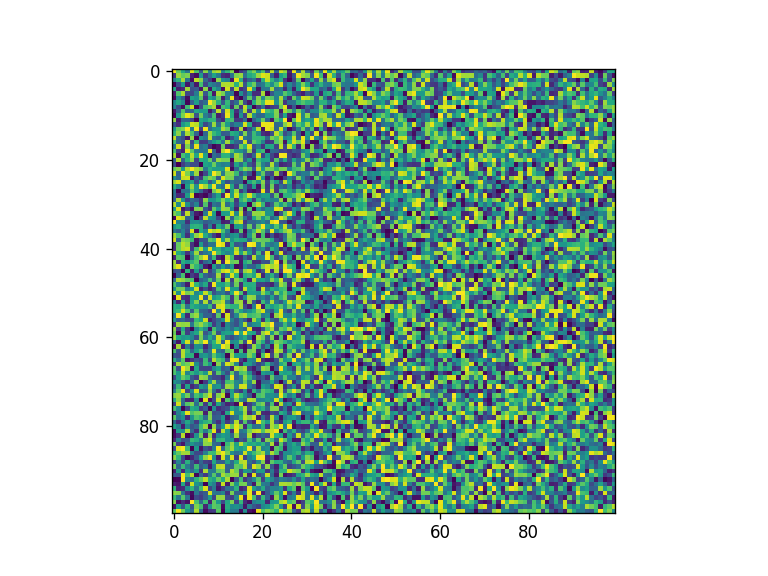

In [133]:
#Create initial random pixel distribution 
x0 = np.random.rand(x_pixel, y_pixel) 
x0_flatten = x0.flatten()

fig = plt.figure() 
plt.imshow(x0)

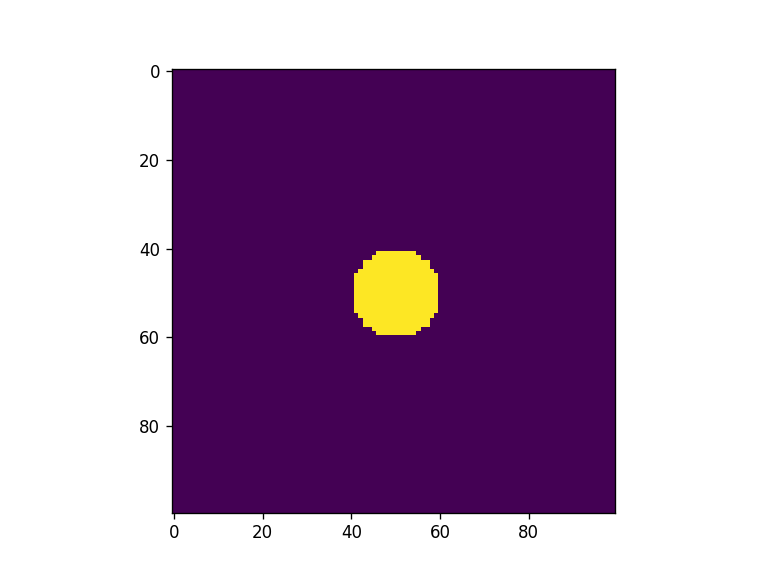

In [134]:
#create target matrix (central cricular pattern) 
xi = np.arange(x_pixel)
yi = np.arange(y_pixel)
XX, YY = np.meshgrid(xi,yi)

target = np.zeros((x_pixel, y_pixel))
target[np.where(((XX-x_pixel/2)**2 + (YY-y_pixel/2)**2) < 10**2)] = 1 

target_flat = target.flatten()

fig = plt.figure() 
plt.imshow(target)

## Optimization framework

The optimization framework passes through the definition of loss functions. Here simply they compare the propagation against a defined target. The loss function takes the propagation method as parameter, so it that different parameters can be tested. 

In [82]:
#Define loss functions 
def mseloss(x, mask, screen, wavelength, target, propag="bluestein"): 
    import jax.numpy as jnp 
    
    prop_x =  jnp.abs(moe.optimizer.propagate(jnp.reshape(x, (len(screen.x), len(screen.y))), mask, screen, wavelength, propagation_method=propag))
    
    diff = jnp.abs(prop_x/jnp.sum(prop_x) - target/jnp.max(target))**2
     
    res = jnp.mean(diff)

    return res


def logloss(x, mask, screen, wavelength, target=target_flat, propag="bluestein", use_timer=True): 
    import jax.numpy as jnp 
    
    prop_x = jnp.abs(moe.optimizer.propagate(jnp.reshape(x, (x_pixel, y_pixel)), mask, screen, wavelength, propagation_method=propag, use_timer=use_timer).flatten())
    prop_x = jnp.reshape(prop_x, (x_pixel, y_pixel))
    midx, midy = int(x_pixel/2), int(y_pixel/2)
    target = jnp.reshape(target, (x_pixel, y_pixel))
    
    res = jnp.log(np.sum(((prop_x/jnp.max(prop_x)/(prop_x[(midx,midy)]/jnp.max(prop_x)) - target/jnp.max(target))**2)))
    
    return res

In [83]:
# Create Aperture
aperture = moe.generate.create_empty_aperture(-aperture_width/2, aperture_width/2, x_pixel, -aperture_height/2, aperture_height/2, y_pixel)

In [84]:
# Creates a screen in YZ plane with [-aperture_height/2, aperture_height/2] at zdist 
ymin, ymax = -aperture_height/2, aperture_height/2
xmin, xmax = -aperture_width/2, aperture_width/2

zdist = 0.00015

x = np.linspace(xmin, xmax, x_pixel)
y = np.linspace(ymin, ymax, y_pixel)
z = np.array([zdist])

screen = moe.Screen(x,y,z)

In [85]:
#optimize using the optimizer module  and Bluestein propagation (default) 
# the initial guess is the randomly initialized x0 
solution = moe.optimizer.optimize(mseloss, x0_flatten, args1=[aperture, screen, wavelength, target], verbose = 1, ftol=1e-4, )

Elapsed: 0:00:00.015930
Elapsed: 0:00:00.014436
Elapsed: 0:00:00.040322
Elapsed: 0:00:00.015432
Elapsed: 0:00:00.015930
Elapsed: 0:00:00.040323
Elapsed: 0:00:00.014437
Elapsed: 0:00:00.014436
Elapsed: 0:00:00.040326
Elapsed: 0:00:00.014935
Elapsed: 0:00:00.017424
Elapsed: 0:00:00.045301
Elapsed: 0:00:00.014935
Elapsed: 0:00:00.015432
Elapsed: 0:00:00.039852
Elapsed: 0:00:00.014436
Elapsed: 0:00:00.014934
Elapsed: 0:00:00.039327
Elapsed: 0:00:00.016428
Elapsed: 0:00:00.014438
Elapsed: 0:00:00.046794
Elapsed: 0:00:00.019913
Elapsed: 0:00:00.016926
Elapsed: 0:00:00.039328
Elapsed: 0:00:00.014935
Elapsed: 0:00:00.014436
Elapsed: 0:00:00.038830
Elapsed: 0:00:00.014934
Elapsed: 0:00:00.016926
Elapsed: 0:00:00.041318
Elapsed: 0:00:00.014935
Elapsed: 0:00:00.014436
Elapsed: 0:00:00.040821
Elapsed: 0:00:00.015930
Elapsed: 0:00:00.029371
Elapsed: 0:00:00.041319
Elapsed: 0:00:00.014436
Elapsed: 0:00:00.013939
Elapsed: 0:00:00.050279
Elapsed: 0:00:00.015432
Elapsed: 0:00:00.027401
Elapsed: 0:00:00

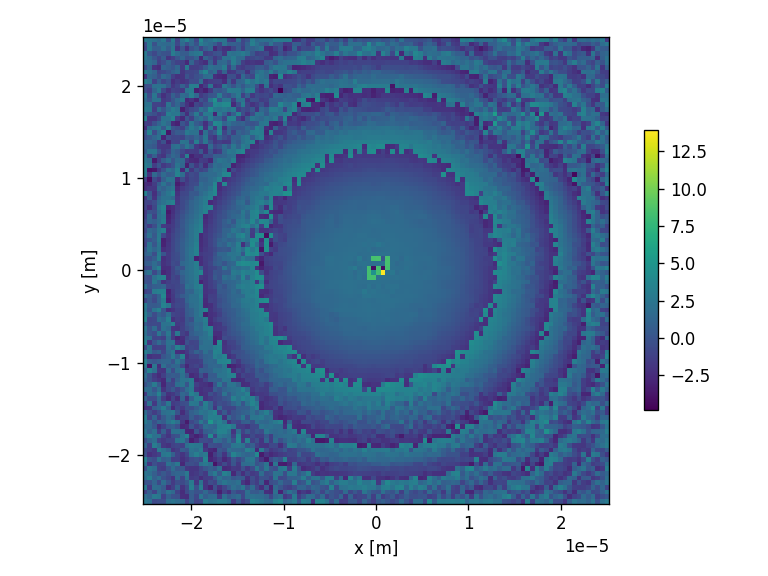

In [86]:
x = solution.x
xar = np.reshape(x, (x_pixel, y_pixel))

#just for plotting the phase with dimensions 
aperture.aperture = xar 
moe.plotting.plot_aperture(aperture)

Elapsed: 0:00:00.015431
Elapsed: 0:00:00.014934


Text(0.5, 1.0, 'Target')

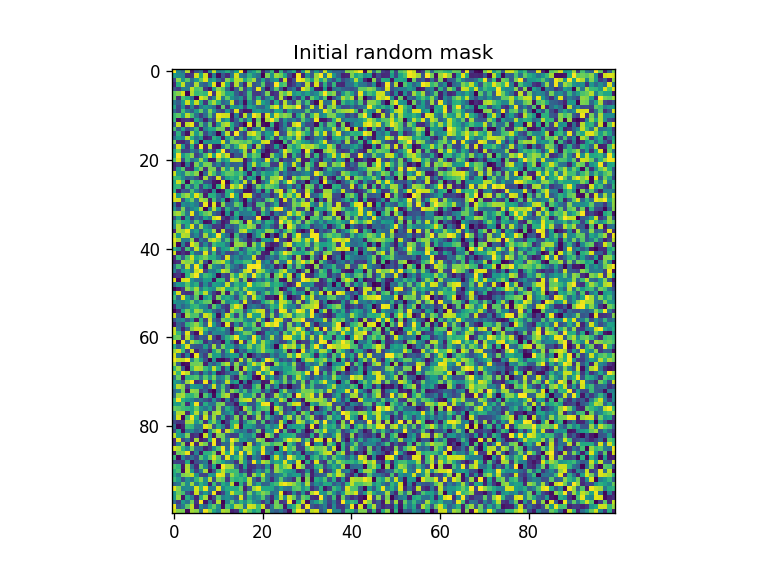

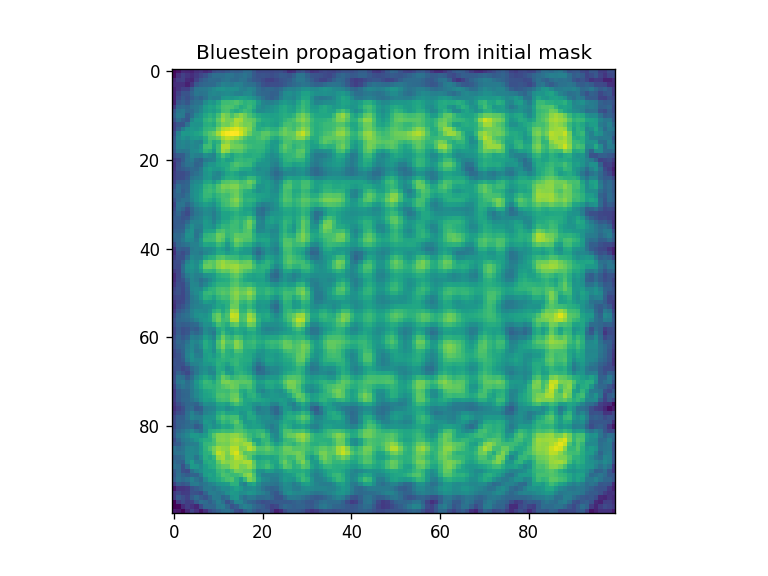

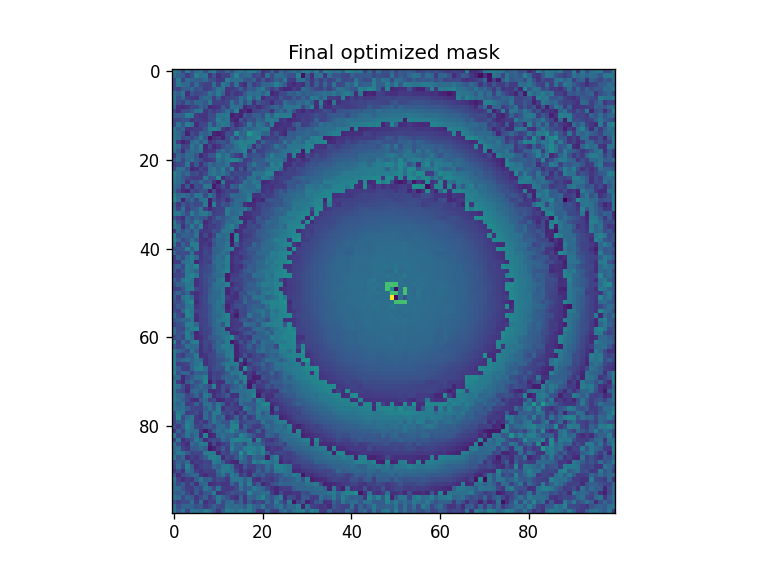

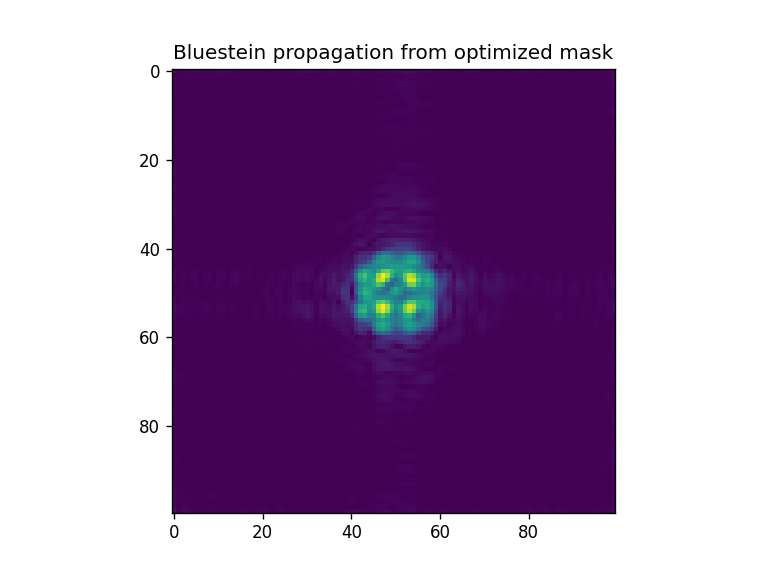

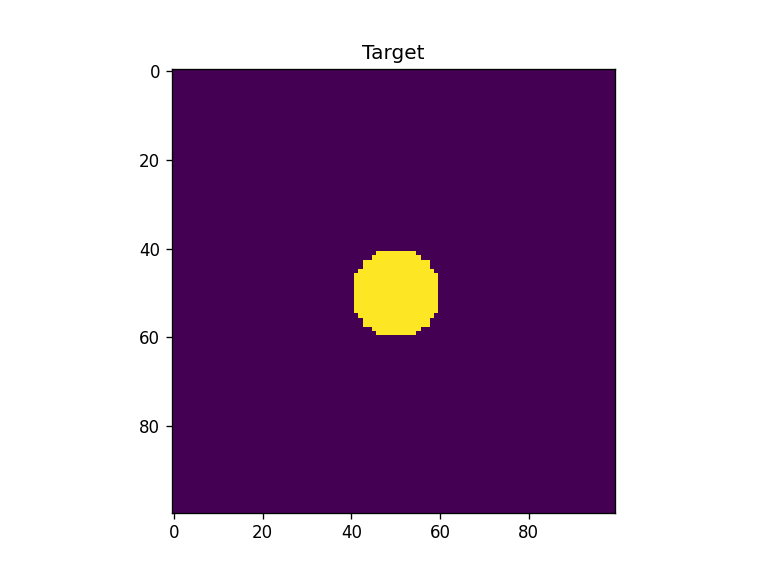

In [87]:
fig = plt.figure() 
xar2 = np.reshape(x0_flatten, (x_pixel, y_pixel))
plt.imshow(xar2) 
plt.title("Initial random mask")

fig = plt.figure() 
plt.imshow(np.abs(moe.optimizer.propagate(xar2, aperture, screen, wavelength) ) )
plt.title("Bluestein propagation from initial mask")


fig = plt.figure() 
xar3 = np.reshape(x, (x_pixel, y_pixel))
plt.imshow(xar3) 
plt.title("Final optimized mask")

fig = plt.figure() 
plt.imshow(np.abs(moe.optimizer.propagate(xar3, aperture, screen, wavelength) ) )
plt.title("Bluestein propagation from optimized mask")

fig = plt.figure() 
plt.imshow(np.reshape(target, (x_pixel, y_pixel)) )
plt.title("Target")

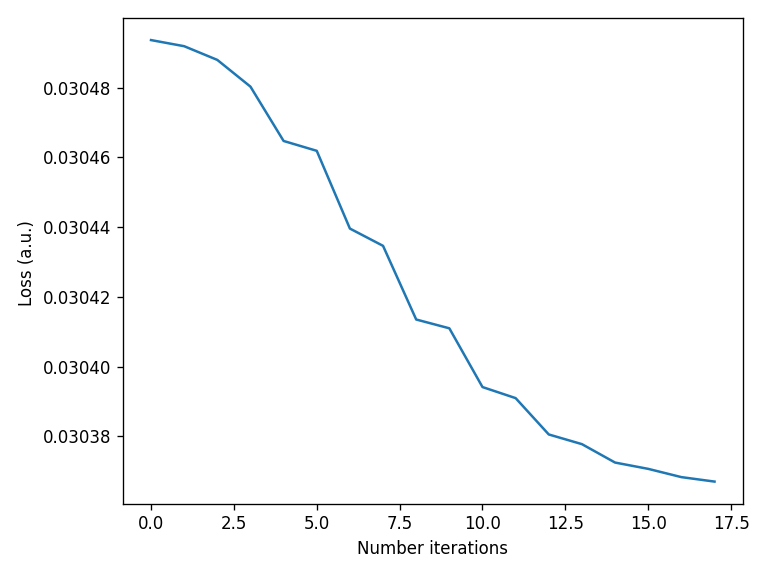

In [88]:
loss_vector = solution.loss_history 

plt.figure() 
plt.plot(loss_vector)
plt.xlabel("Number iterations")
plt.ylabel("Loss (a.u.) ")
plt.tight_layout() 

### Optimization with logging 

The optimizer module provides an embedded logger to allow to track the optimization loss and store the parameters at each iteration step. 

In [89]:
# x0_flatten is your initial guess vector
logger, logfile_txt, logfile_bin, batch_list, iter_counter, batch_size, fh = moe.optimizer.setup_optimizer_logger_batch( x_size=len(x0_flatten), \
                                                                                                       batch_size=1, log_dir="logs", name="test")



In [90]:
#optimize using the optimizer module  and Bluestein propagation (default) 
# the initial guess is the randomly initialized x0 
solution = moe.optimizer.optimize(mseloss, x0_flatten, args1=[aperture, screen, wavelength, target], verbose = 1, ftol=1e-4, logger=logger, \
                                  logfile_bin=logfile_bin, batch_list=batch_list, batch_size=batch_size, iter_counter=iter_counter, fh=fh)

Elapsed: 0:00:00.016428
Elapsed: 0:00:00.014936
Elapsed: 0:00:00.040821
Elapsed: 0:00:00.014933
Elapsed: 0:00:00.014436
Elapsed: 0:00:00.040820
Elapsed: 0:00:00.016421
Elapsed: 0:00:00.014437
Elapsed: 0:00:00.041815
Elapsed: 0:00:00.014438
Elapsed: 0:00:00.014436
Elapsed: 0:00:00.040323
Elapsed: 0:00:00.014935
Elapsed: 0:00:00.014934
Elapsed: 0:00:00.039326
Elapsed: 0:00:00.014437
Elapsed: 0:00:00.013939
Elapsed: 0:00:00.038830
Elapsed: 0:00:00.018419
Elapsed: 0:00:00.014437
Elapsed: 0:00:00.039325
Elapsed: 0:00:00.014437
Elapsed: 0:00:00.014437
Elapsed: 0:00:00.039327
Elapsed: 0:00:00.014437
Elapsed: 0:00:00.014437
Elapsed: 0:00:00.038829
Elapsed: 0:00:00.014437
Elapsed: 0:00:00.014435
Elapsed: 0:00:00.038829
Elapsed: 0:00:00.014436
Elapsed: 0:00:00.013939
Elapsed: 0:00:00.039328
Elapsed: 0:00:00.013939
Elapsed: 0:00:00.013939
Elapsed: 0:00:00.038830
Elapsed: 0:00:00.018916
Elapsed: 0:00:00.013939
Elapsed: 0:00:00.038830
Elapsed: 0:00:00.014436
Elapsed: 0:00:00.014935
Elapsed: 0:00:00

Elapsed: 0:00:00.026882
Elapsed: 0:00:00.018918


Text(0.5, 1.0, 'Target')

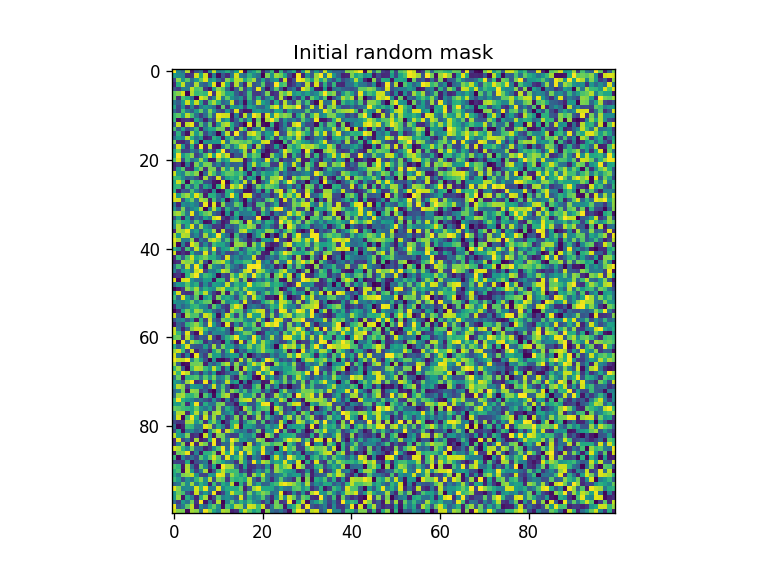

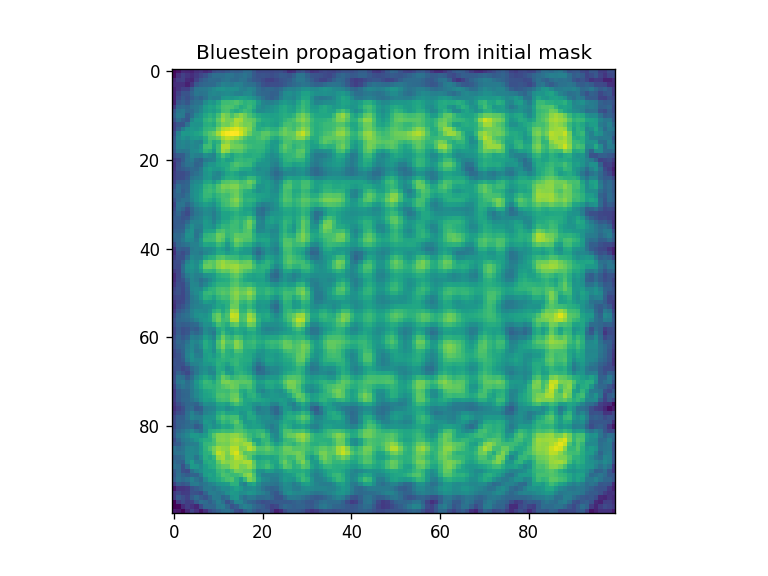

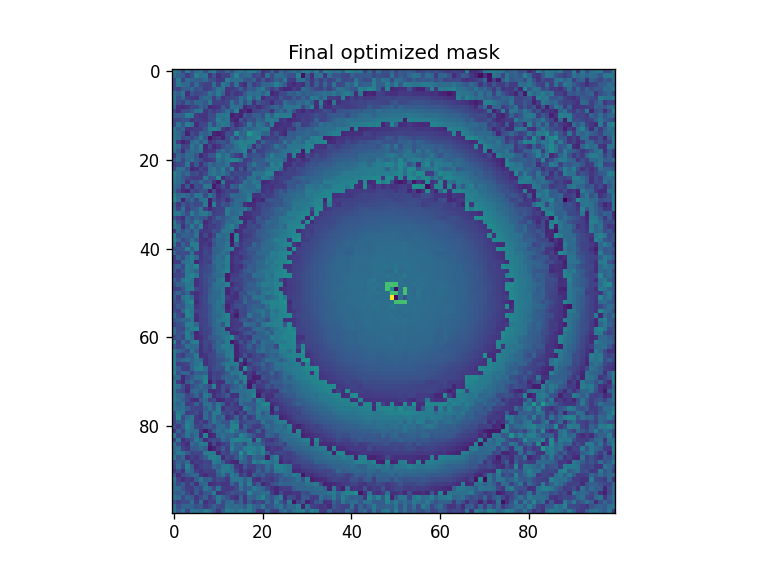

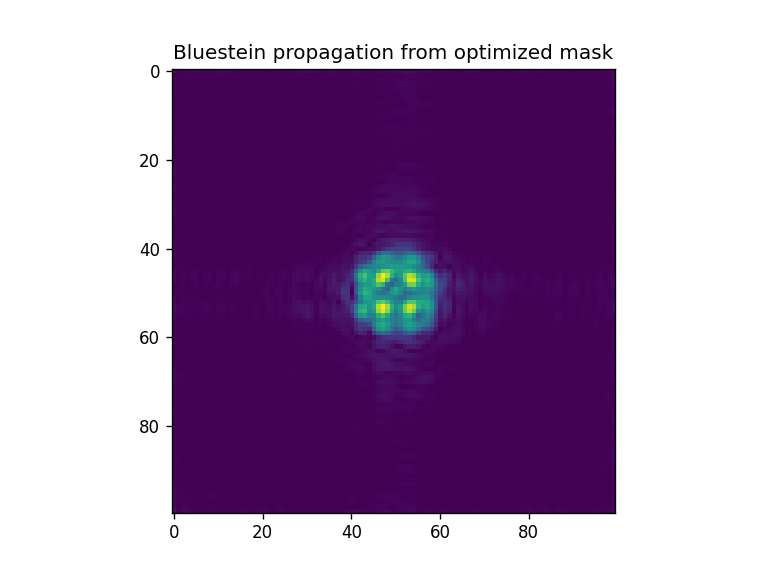

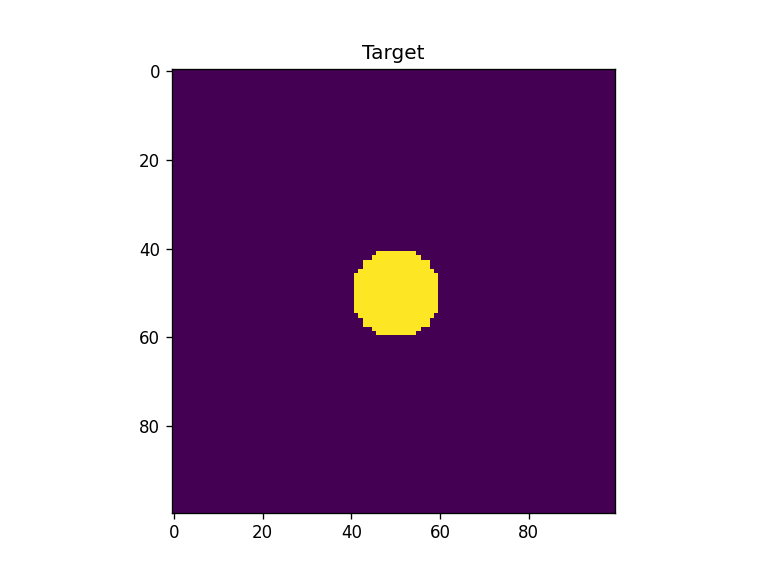

In [91]:
x = solution.x
xar = np.reshape(x, (x_pixel, y_pixel))

fig = plt.figure() 
xar2 = np.reshape(x0_flatten, (x_pixel, y_pixel))
plt.imshow(xar2) 
plt.title("Initial random mask")

fig = plt.figure() 
plt.imshow(np.abs(moe.optimizer.propagate(xar2, aperture, screen, wavelength) ) )
plt.title("Bluestein propagation from initial mask")


fig = plt.figure() 
xar3 = np.reshape(x, (x_pixel, y_pixel))
plt.imshow(xar3) 
plt.title("Final optimized mask")

fig = plt.figure() 
plt.imshow(np.abs(moe.optimizer.propagate(xar3, aperture, screen, wavelength) ) )
plt.title("Bluestein propagation from optimized mask")

fig = plt.figure() 
plt.imshow(np.reshape(target, (x_pixel, y_pixel)) )
plt.title("Target")

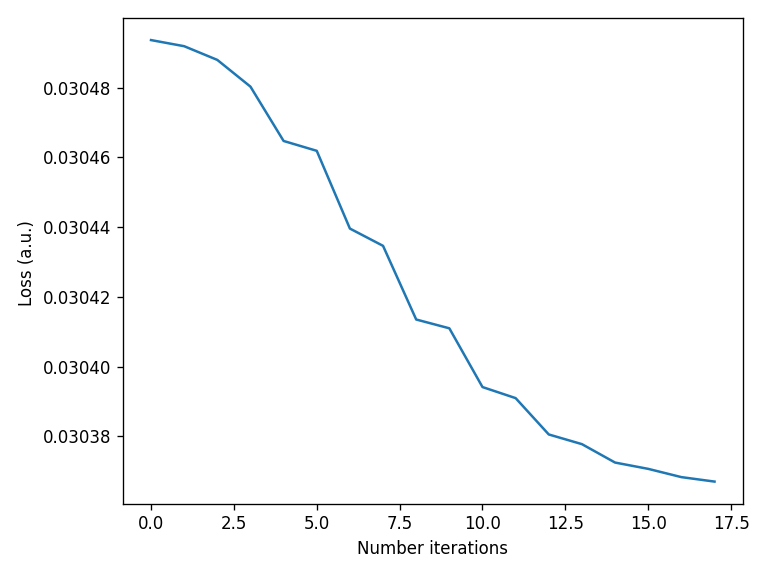

In [92]:
loss_vector = solution.loss_history 

plt.figure() 
plt.plot(loss_vector)
plt.xlabel("Number iterations")
plt.ylabel("Loss (a.u.) ")
plt.tight_layout() 

### Optimization with different forward propagators 

Below we demonstrate several optimizations using Bluestein, ASM and SASM propagators in the forward step. All of them yield acceptable inverse designed masks. 

#### Bluestein (default) 

In [93]:
#optimize using the optimizer module  and Bluestein propagation (default) 
# the initial guess is the randomly initialized x0 
solution = moe.optimizer.optimize(logloss, x0_flatten, args1=[aperture, screen, wavelength, target, "bluestein", False], verbose = 1, ftol=1e-4)

`ftol` termination condition is satisfied.
Function evaluations 697, initial cost 4.0572e+01, final cost 3.6896e+00, first-order optimality 9.81e-04.


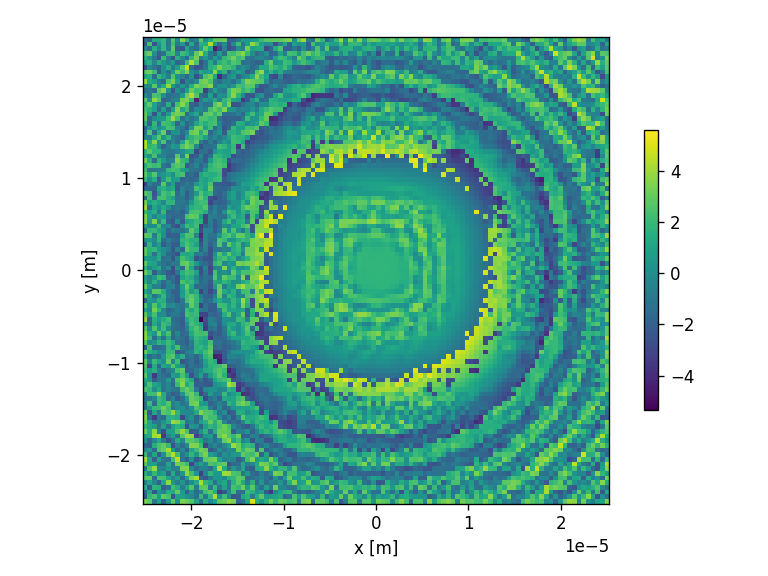

In [94]:
x = solution.x
xar = np.reshape(x, (x_pixel, y_pixel))

#just for plotting the phase with dimensions 
aperture.aperture = xar 
moe.plotting.plot_aperture(aperture)

Elapsed: 0:00:00.016428
Elapsed: 0:00:00.014935


Text(0.5, 1.0, 'Target')

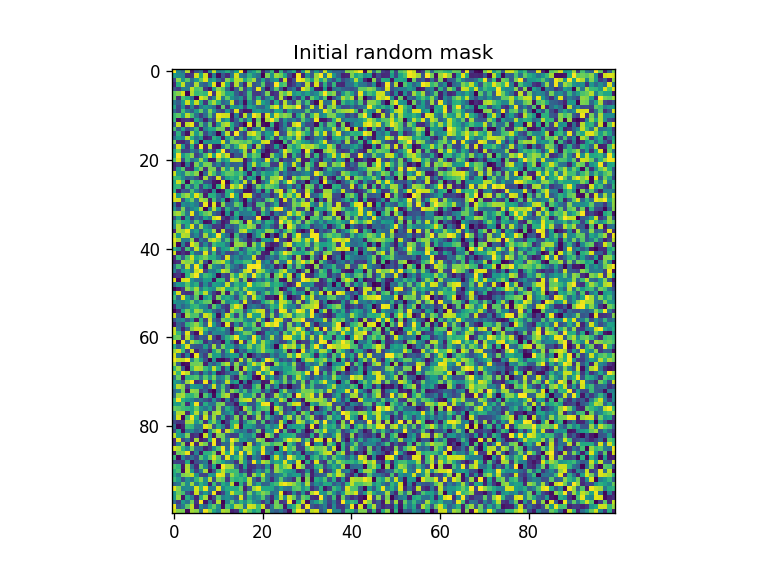

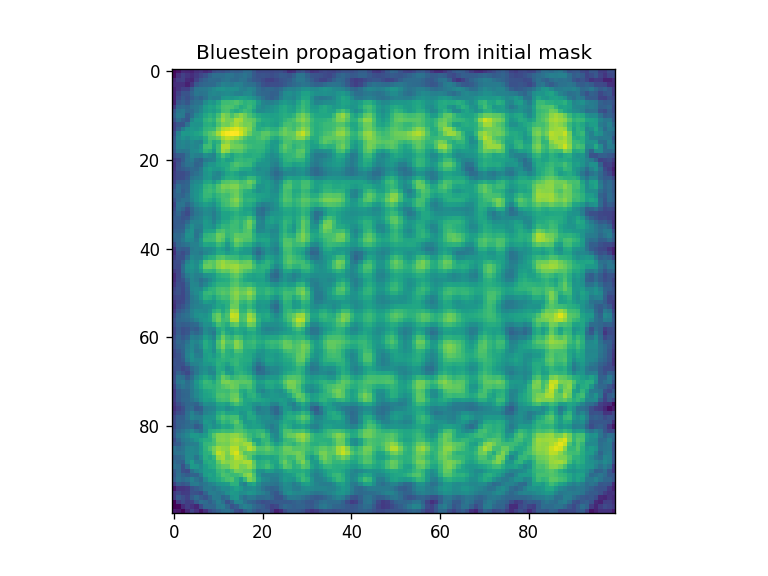

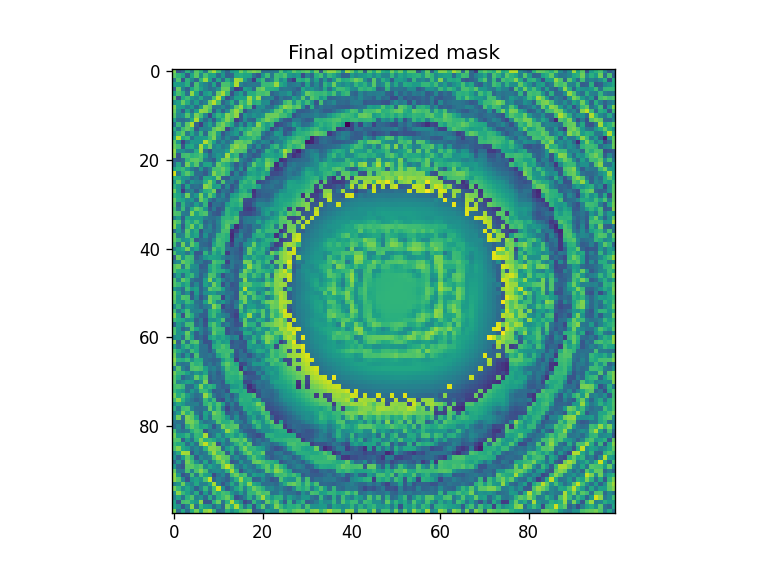

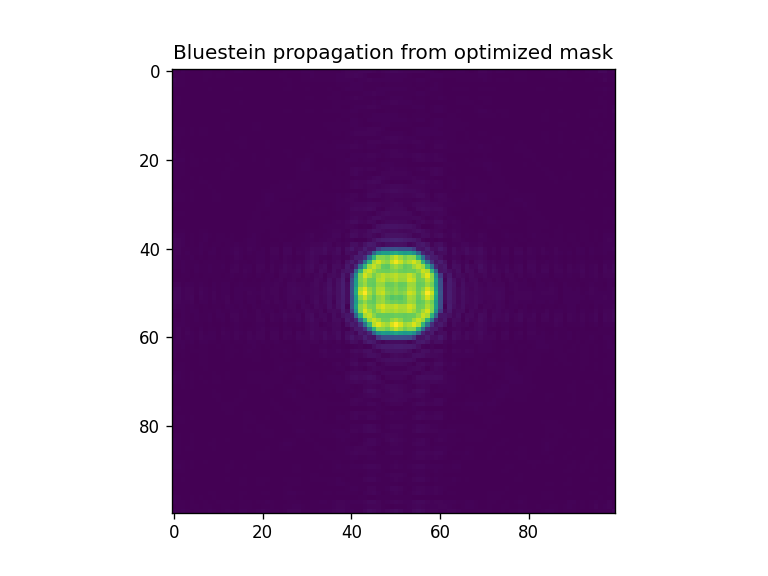

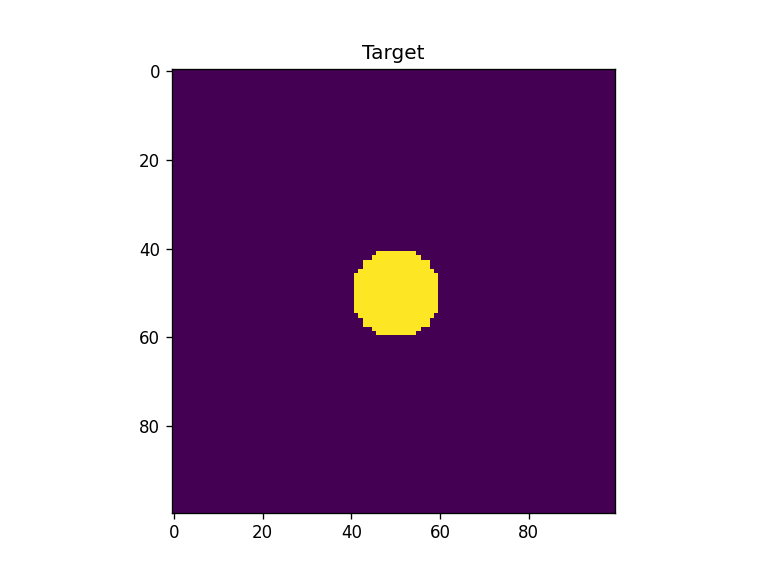

In [95]:
fig = plt.figure() 
xar2 = np.reshape(x0_flatten, (x_pixel, y_pixel))
plt.imshow(xar2) 
plt.title("Initial random mask")

fig = plt.figure() 
plt.imshow(np.abs(moe.optimizer.propagate(xar2, aperture, screen, wavelength) ) )
plt.title("Bluestein propagation from initial mask")


fig = plt.figure() 
xar3 = np.reshape(x, (x_pixel, y_pixel))
plt.imshow(xar3) 
plt.title("Final optimized mask")

fig = plt.figure() 
plt.imshow(np.abs(moe.optimizer.propagate(xar3, aperture, screen, wavelength) ) )
plt.title("Bluestein propagation from optimized mask")

fig = plt.figure() 
plt.imshow(np.reshape(target, (x_pixel, y_pixel)) )
plt.title("Target")

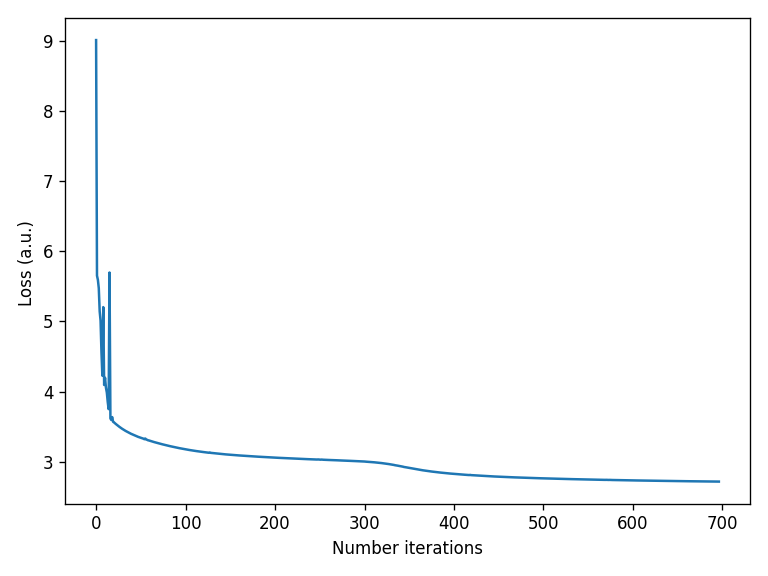

In [96]:
loss_vector = solution.loss_history 

plt.figure() 
plt.plot(loss_vector)
plt.xlabel("Number iterations")
plt.ylabel("Loss (a.u.) ")
plt.tight_layout() 

#### ASM

In [97]:
#optimize using the optimizer module  and Bluestein propagation (default) 
# the initial guess is the randomly initialized x0 
solution = moe.optimizer.optimize(logloss, x0_flatten, args1=[aperture, screen, wavelength, target, "ASM", False], verbose = 1, ftol=1e-4,)

`ftol` termination condition is satisfied.
Function evaluations 510, initial cost 4.1513e+01, final cost 3.5448e+00, first-order optimality 1.45e-03.


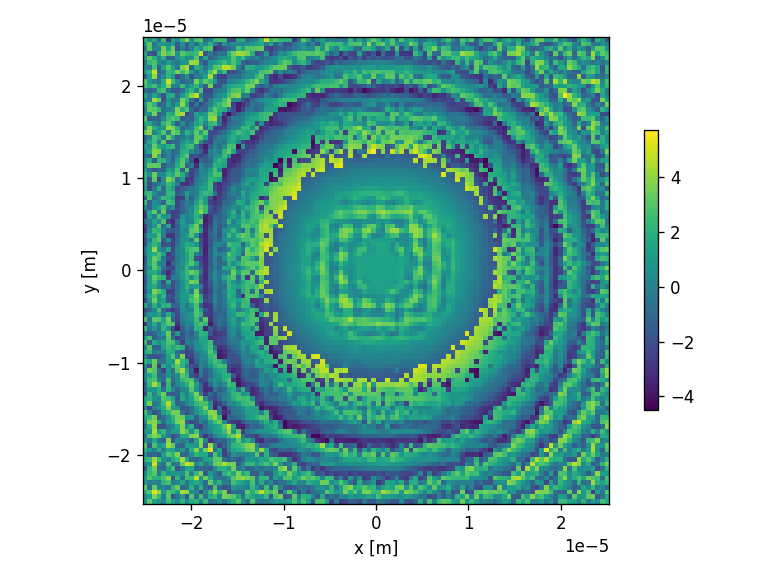

In [98]:
x = solution.x
xar = np.reshape(x, (x_pixel, y_pixel))

#just for plotting the phase with dimensions 
aperture.aperture = xar 
moe.plotting.plot_aperture(aperture)

Elapsed: 0:00:00.024393
Elapsed: 0:00:00.015432


Text(0.5, 1.0, 'Target')

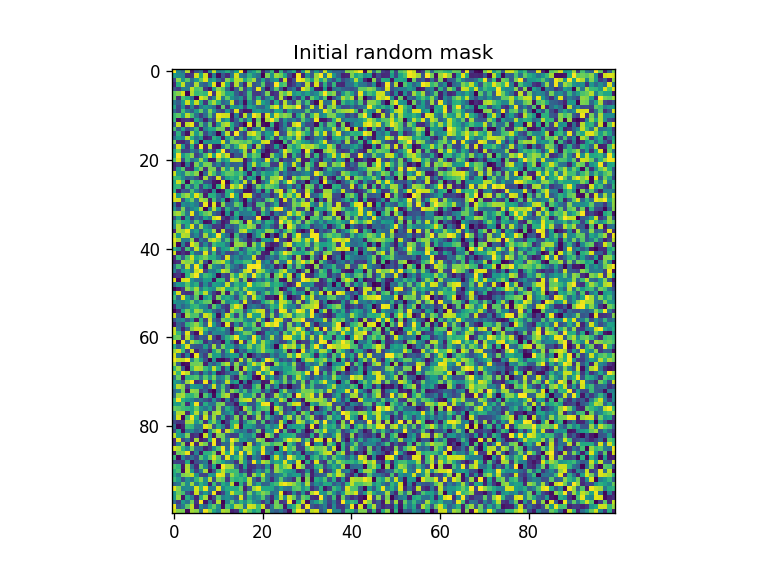

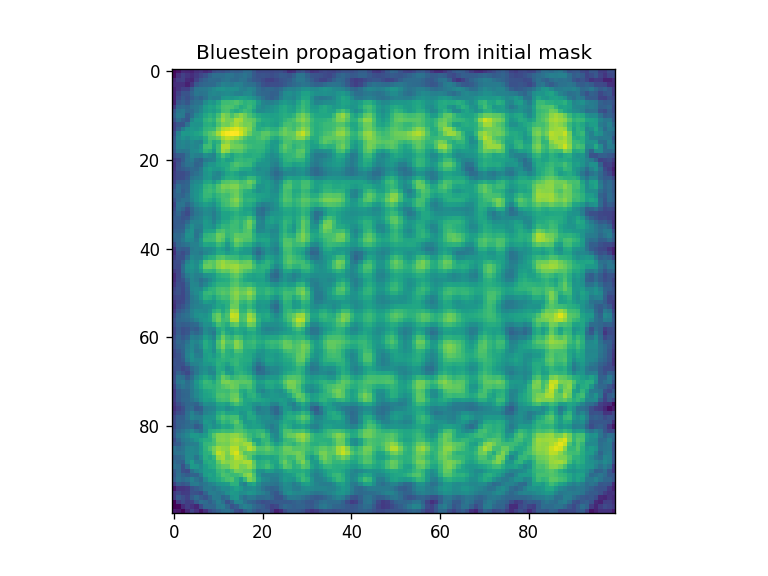

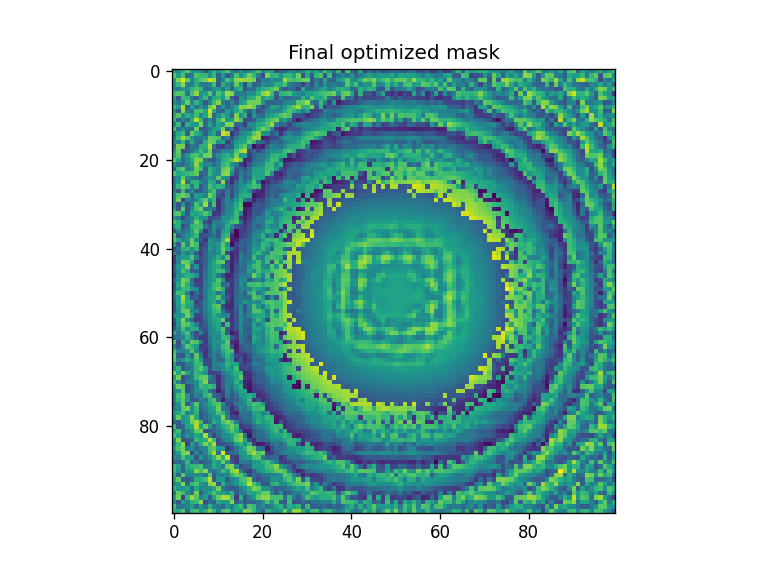

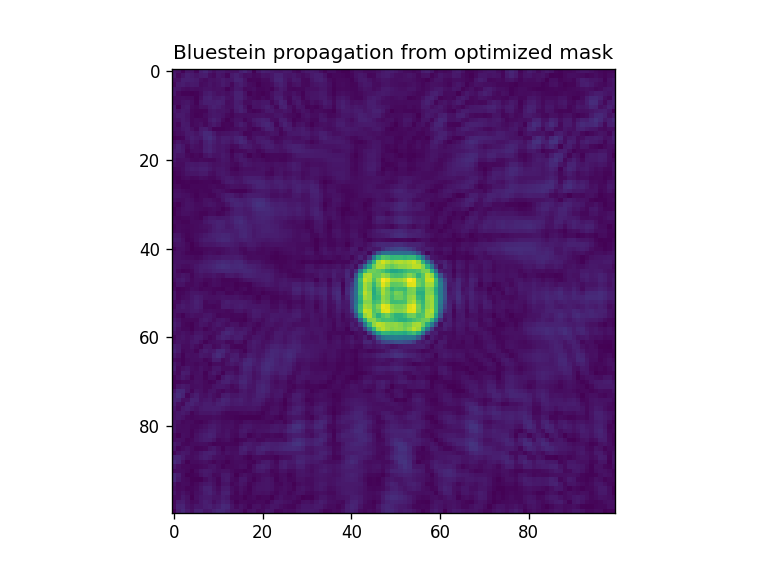

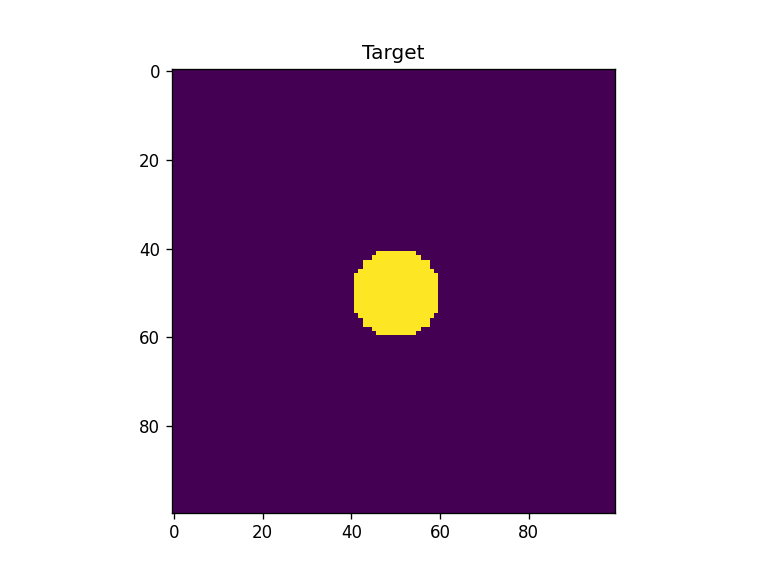

In [99]:
fig = plt.figure() 
xar2 = np.reshape(x0_flatten, (x_pixel, y_pixel))
plt.imshow(xar2) 
plt.title("Initial random mask")

fig = plt.figure() 
plt.imshow(np.abs(moe.optimizer.propagate(xar2, aperture, screen, wavelength) ) )
plt.title("Bluestein propagation from initial mask")


fig = plt.figure() 
xar3 = np.reshape(x, (x_pixel, y_pixel))
plt.imshow(xar3) 
plt.title("Final optimized mask")

fig = plt.figure() 
plt.imshow(np.abs(moe.optimizer.propagate(xar3, aperture, screen, wavelength) ) )
plt.title("Bluestein propagation from optimized mask")

fig = plt.figure() 
plt.imshow(np.reshape(target, (x_pixel, y_pixel)) )
plt.title("Target")

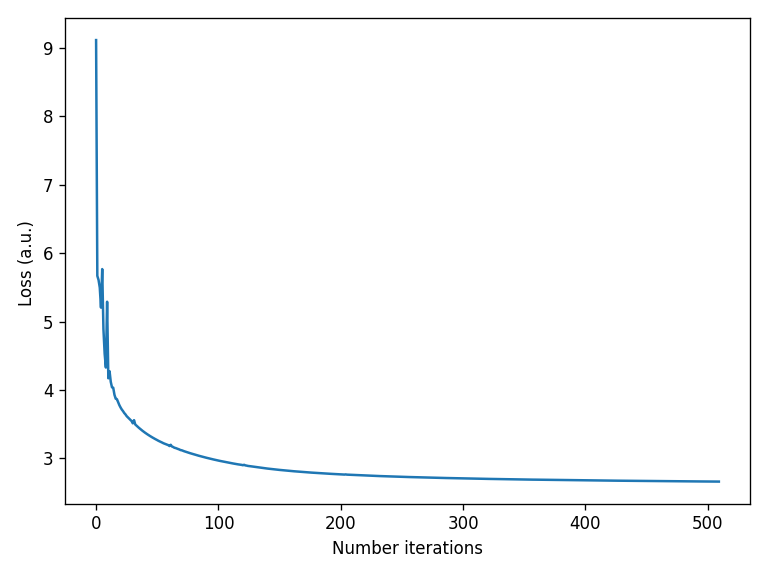

In [100]:
loss_vector = solution.loss_history 

plt.figure() 
plt.plot(loss_vector)
plt.xlabel("Number iterations")
plt.ylabel("Loss (a.u.) ")
plt.tight_layout() 

#### SASM

In [101]:
#optimize using the optimizer module  and Bluestein propagation (default) 
# the initial guess is the randomly initialized x0 
solution = moe.optimizer.optimize(logloss, x0_flatten, args1=[aperture, screen, wavelength, target, "SASM", False], verbose = 1, ftol=1e-4,)

`ftol` termination condition is satisfied.
Function evaluations 530, initial cost 4.0713e+01, final cost 3.9720e+00, first-order optimality 9.30e-04.


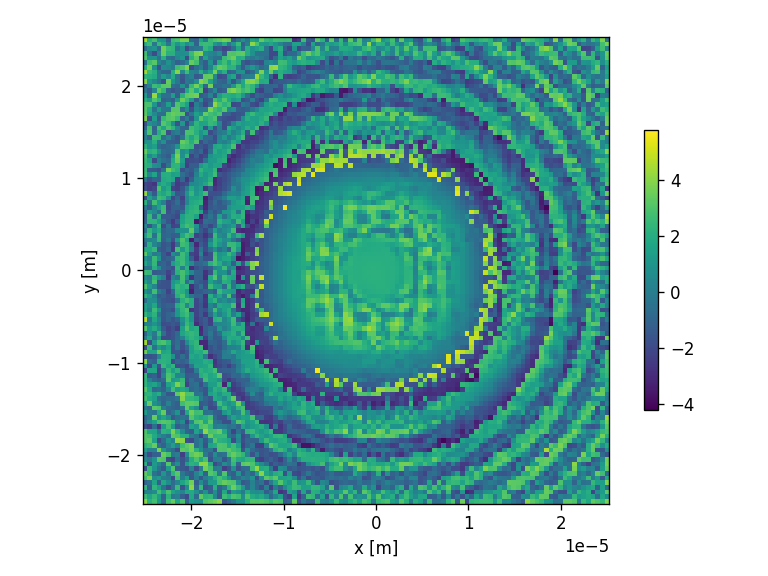

In [102]:
x = solution.x
xar = np.reshape(x, (x_pixel, y_pixel))

#just for plotting the phase with dimensions 
aperture.aperture = xar 
moe.plotting.plot_aperture(aperture)

Elapsed: 0:00:00.017424
Elapsed: 0:00:00.015930


Text(0.5, 1.0, 'Target')

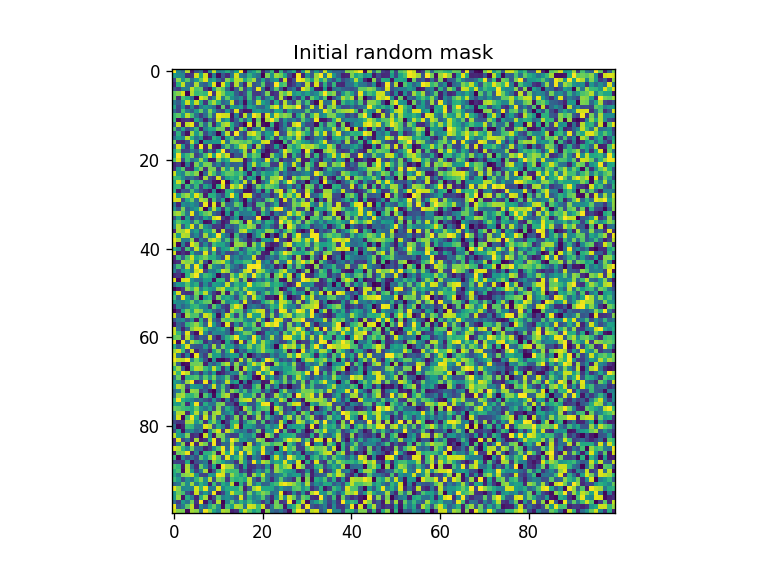

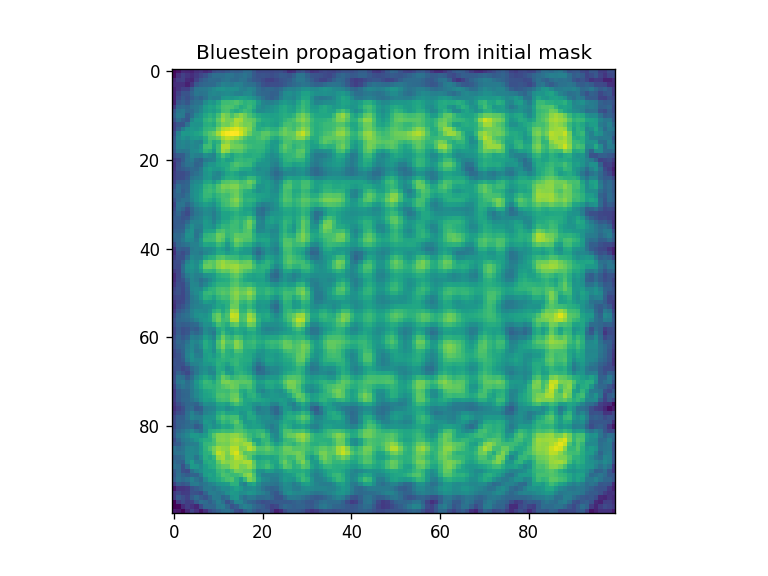

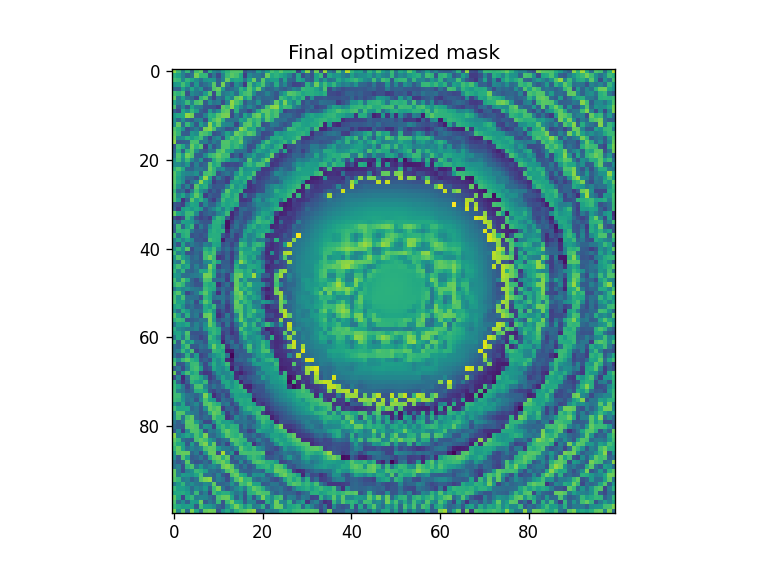

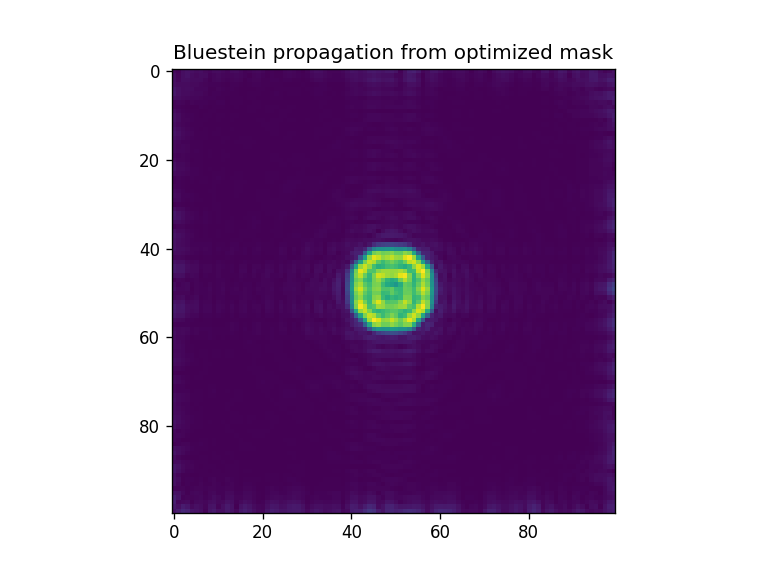

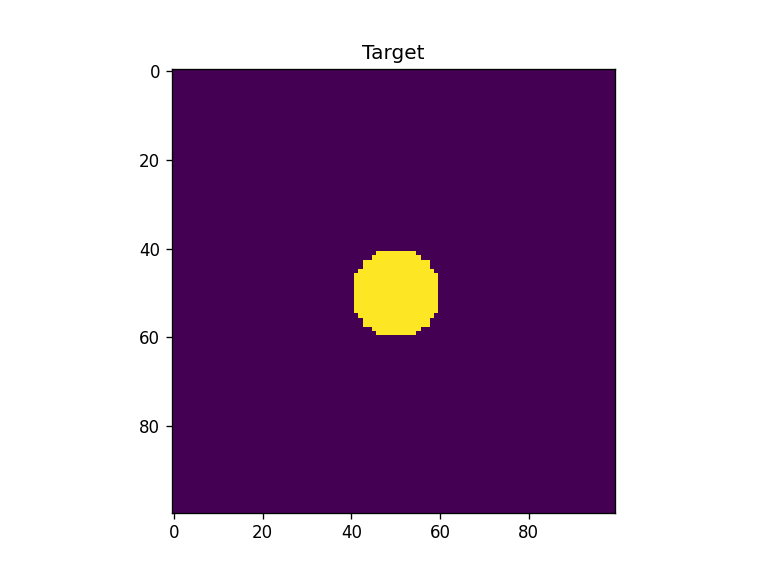

In [103]:
fig = plt.figure() 
xar2 = np.reshape(x0_flatten, (x_pixel, y_pixel))
plt.imshow(xar2) 
plt.title("Initial random mask")

fig = plt.figure() 
plt.imshow(np.abs(moe.optimizer.propagate(xar2, aperture, screen, wavelength) ) )
plt.title("Bluestein propagation from initial mask")


fig = plt.figure() 
xar3 = np.reshape(x, (x_pixel, y_pixel))
plt.imshow(xar3) 
plt.title("Final optimized mask")

fig = plt.figure() 
plt.imshow(np.abs(moe.optimizer.propagate(xar3, aperture, screen, wavelength) ) )
plt.title("Bluestein propagation from optimized mask")

fig = plt.figure() 
plt.imshow(np.reshape(target, (x_pixel, y_pixel)) )
plt.title("Target")

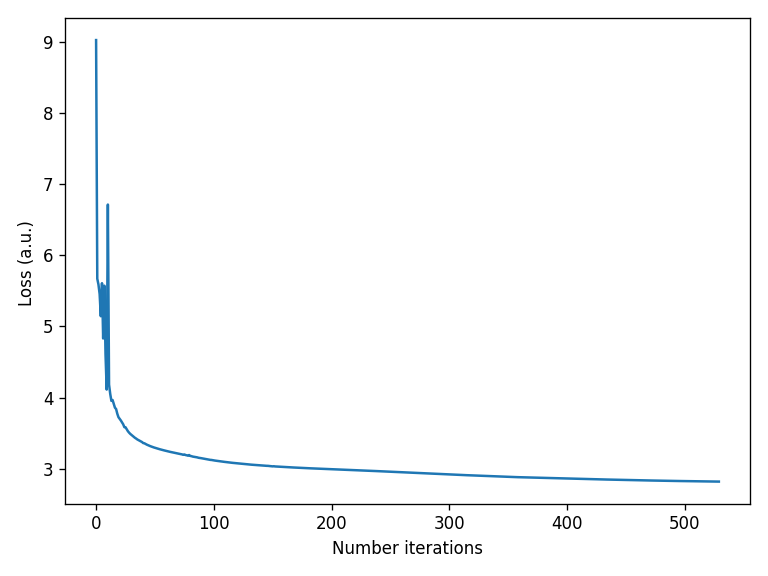

In [104]:
loss_vector = solution.loss_history 

plt.figure() 
plt.plot(loss_vector)
plt.xlabel("Number iterations")
plt.ylabel("Loss (a.u.) ")
plt.tight_layout() 

### Loss function engineering 
We can alter the loss function for whatever suits us best 

In [107]:
def logloss2(x, mask, screen, wavelength, target, propag, use_timer): 
    import jax.numpy as jnp 
    
    prop_x =  jnp.abs(moe.optimizer.propagate(np.reshape(x, (len(screen.x), len(screen.y))), mask, screen, wavelength, propagation_method=propag , use_timer=use_timer))
    
    diff = jnp.abs(prop_x/prop_x[int(len(screen.x)/2), int(len(screen.y)/2)] - target/jnp.max(target))**2
     
    res = jnp.log(jnp.sum(diff))

    return res

In [108]:
## Optimization with ASM 
x0 = np.random.rand(x_pixel, y_pixel) 
x0_flatten = x0.flatten()

x = np.linspace(xmin, xmax, x_pixel)
y = np.linspace(ymin, ymax, y_pixel)
z = np.array([zdist])

screen = moe.Screen(x,y,z)

aperture = moe.generate.create_empty_aperture(-aperture_width/2, aperture_width/2, x_pixel, -aperture_height/2, aperture_height/2, y_pixel)

solution = moe.optimizer.optimize(logloss2, x0_flatten, args1=[aperture, screen, wavelength, target, "ASM", False], verbose = 1, ftol=1e-3,)


`ftol` termination condition is satisfied.
Function evaluations 66, initial cost 3.9460e+01, final cost 3.6099e+00, first-order optimality 5.52e-03.


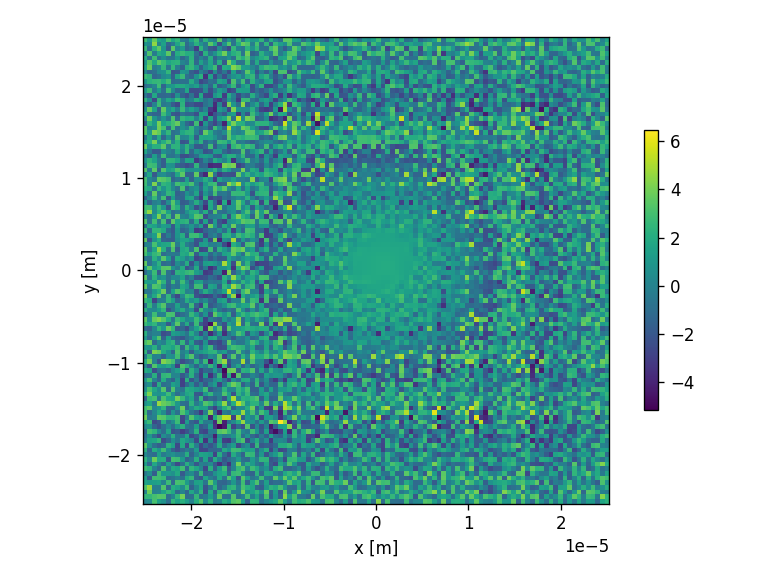

In [109]:
x = solution.x
xar = np.reshape(x, (x_pixel, y_pixel))

#just for plotting the phase with dimensions 
aperture.aperture = xar 
moe.plotting.plot_aperture(aperture)

Elapsed: 0:00:00.016926
Elapsed: 0:00:00.015432


Text(0.5, 1.0, 'Target')

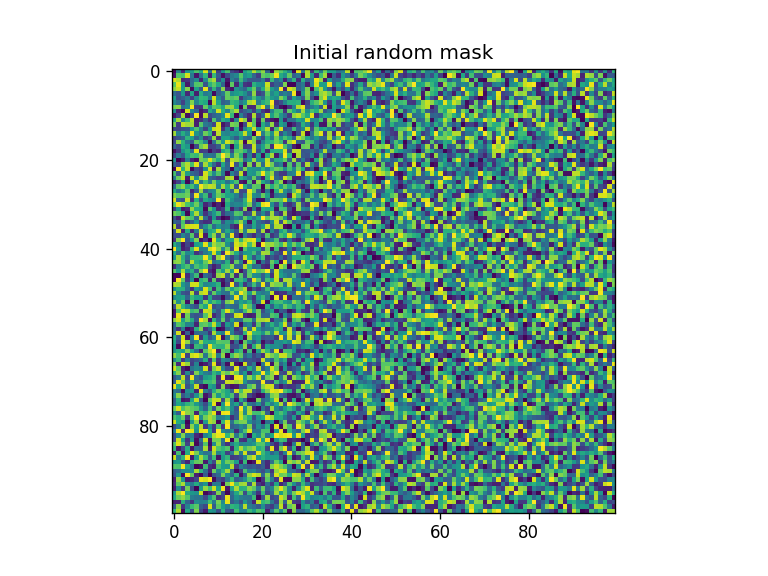

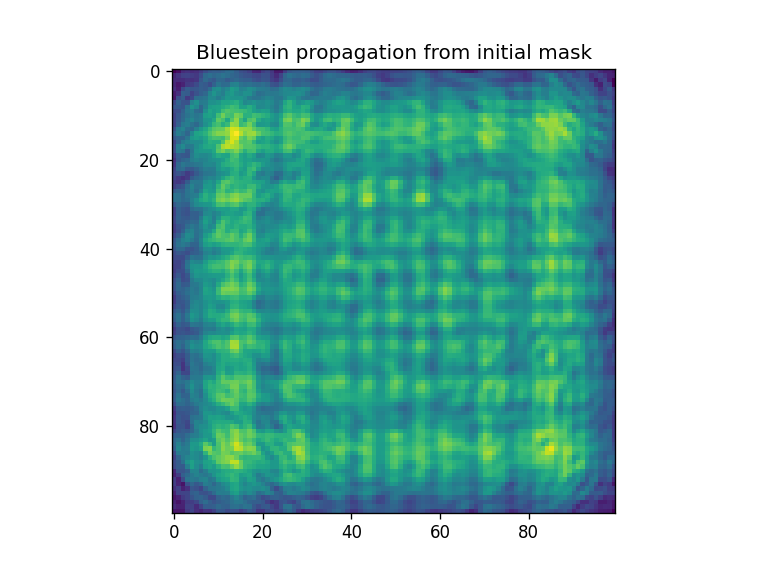

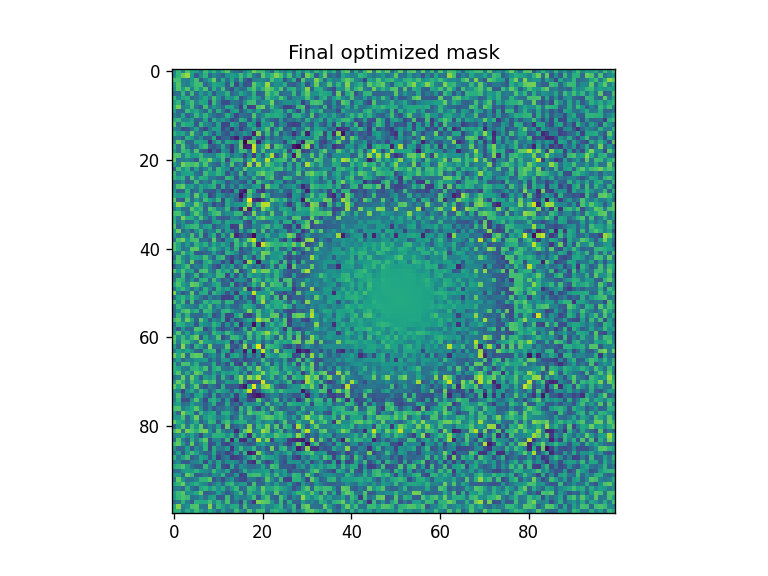

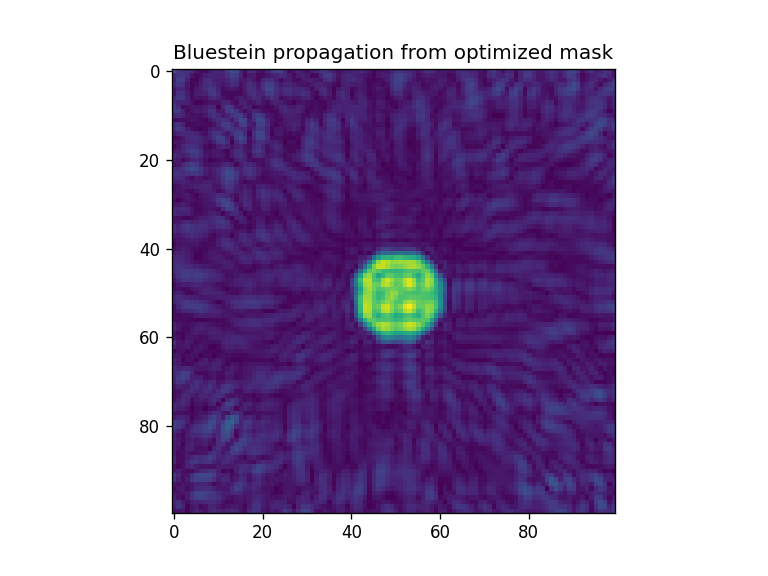

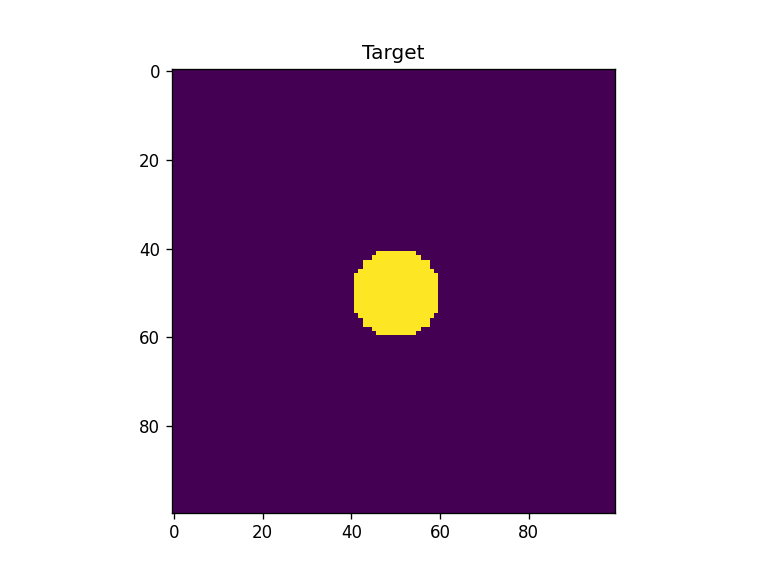

In [110]:
fig = plt.figure() 
xar2 = np.reshape(x0_flatten, (x_pixel, y_pixel))
plt.imshow(xar2) 
plt.title("Initial random mask")

fig = plt.figure() 
plt.imshow(np.abs(moe.optimizer.propagate(xar2, aperture, screen, wavelength) ) )
plt.title("Bluestein propagation from initial mask")


fig = plt.figure() 
xar3 = np.reshape(x, (x_pixel, y_pixel))
plt.imshow(xar3) 
plt.title("Final optimized mask")

fig = plt.figure() 
plt.imshow(np.abs(moe.optimizer.propagate(xar3, aperture, screen, wavelength) ) )
plt.title("Bluestein propagation from optimized mask")

fig = plt.figure() 
plt.imshow(np.reshape(target, (x_pixel, y_pixel)) )
plt.title("Target")

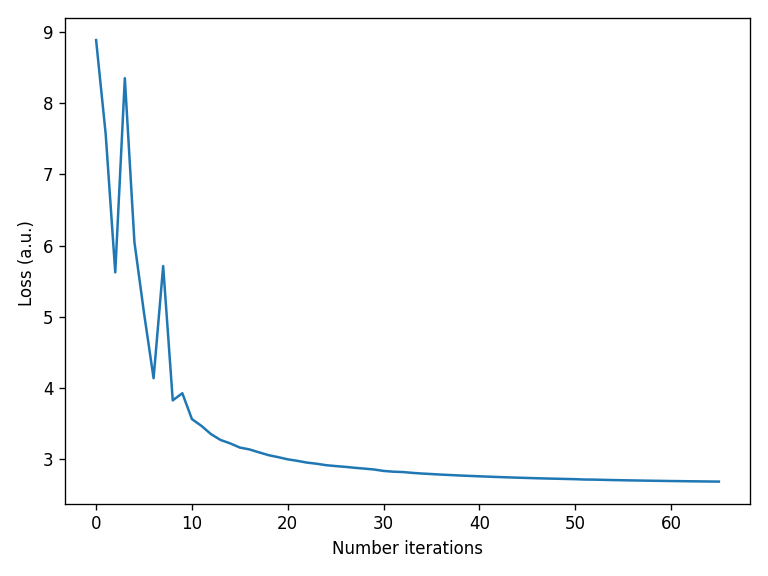

In [111]:
loss_vector = solution.loss_history 

plt.figure() 
plt.plot(loss_vector)
plt.xlabel("Number iterations")
plt.ylabel("Loss (a.u.) ")
plt.tight_layout() 

### Target re-definition 
We can alter the target for what we desire. The target can be generated from analytical or theoretical models, e.g. it could be generated as Airy pattern or Gaussian-Laguerre beam profile. 

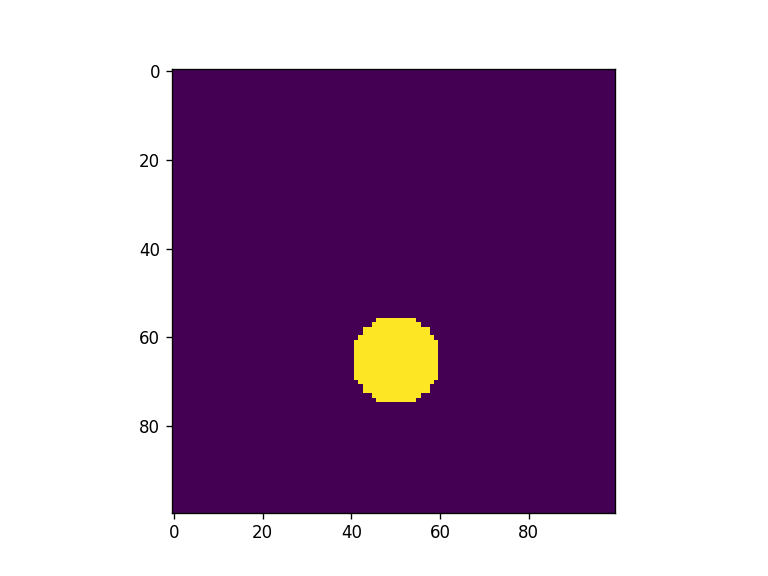

In [112]:
# re-define  target 

#target with offset circle 
xi = np.arange(x_pixel)
yi = np.arange(y_pixel*2)
XX, YY = np.meshgrid(xi,yi)
    
target = np.zeros((x_pixel, y_pixel))
target[np.where(((XX-x_pixel/2- 0)**2 + (YY-y_pixel/2-15)**2) < 10**2)] = 1 


fig = plt.figure() 
plt.imshow(target)

In [113]:
## Optimization with ASM 
x0 = np.random.rand(x_pixel, y_pixel) 
x0_flatten = x0.flatten()

x = np.linspace(xmin, xmax, x_pixel)
y = np.linspace(ymin, ymax, y_pixel)
z = np.array([zdist])

screen = moe.Screen(x,y,z)

aperture = moe.generate.create_empty_aperture(-aperture_width/2, aperture_width/2, x_pixel, -aperture_height/2, aperture_height/2, y_pixel)

In [114]:
solution = moe.optimizer.optimize(logloss2, x0_flatten, args1=[aperture, screen, wavelength, target, "bluestein", False], verbose = 1, ftol=1e-3,)

x = solution.x

`ftol` termination condition is satisfied.
Function evaluations 163, initial cost 3.9079e+01, final cost 6.1378e+00, first-order optimality 3.10e-03.


In [115]:
x = solution.x
xar = np.reshape(x, (x_pixel, y_pixel))


Elapsed: 0:00:00.015931
Elapsed: 0:00:00.015433


Text(0.5, 1.0, 'Target')

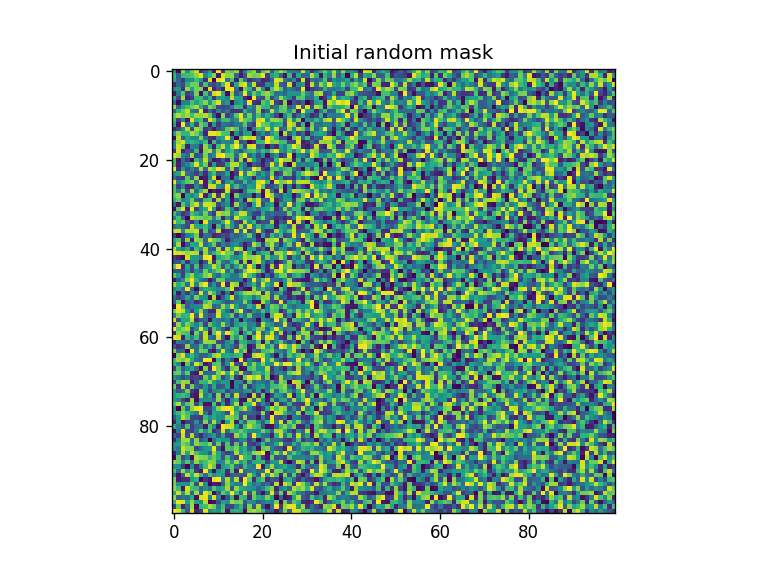

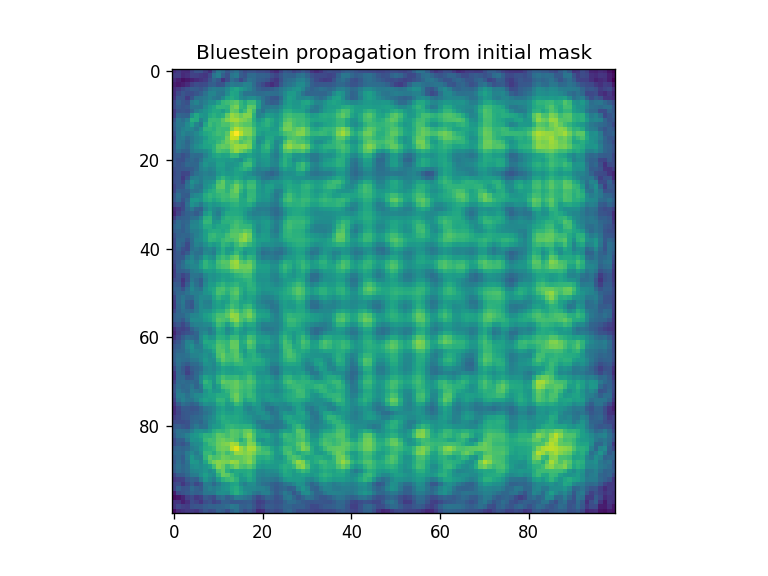

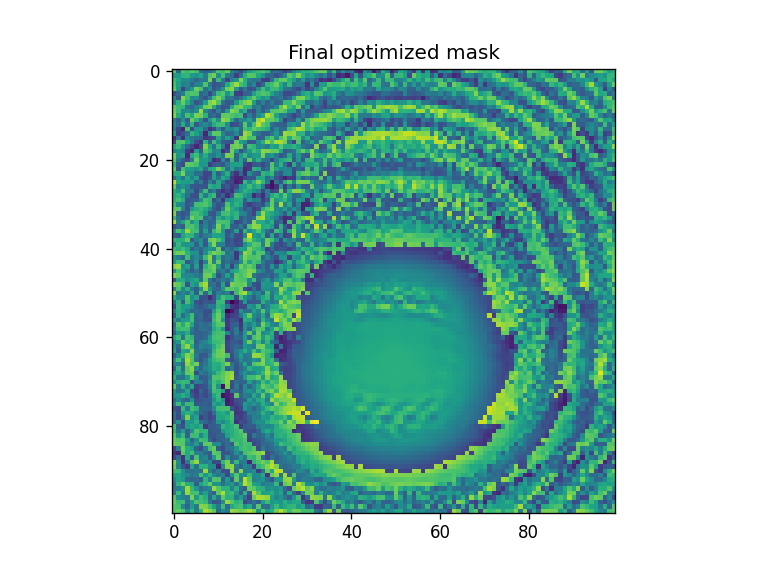

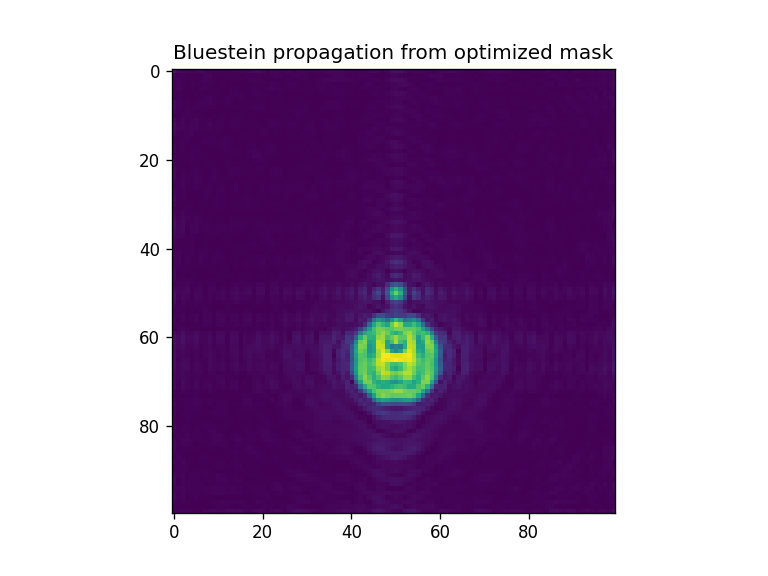

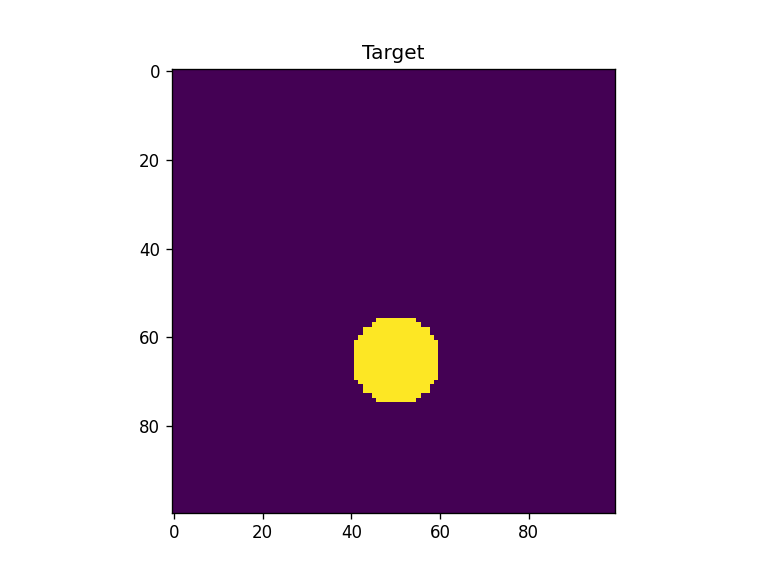

In [116]:
fig = plt.figure() 
xar2 = np.reshape(x0_flatten, (x_pixel, y_pixel))
plt.imshow(xar2) 
plt.title("Initial random mask")

fig = plt.figure() 
plt.imshow(np.abs(moe.optimizer.propagate(xar2, aperture, screen, wavelength) ) )
plt.title("Bluestein propagation from initial mask")


fig = plt.figure() 
xar3 = np.reshape(x, (x_pixel, y_pixel))
plt.imshow(xar3) 
plt.title("Final optimized mask")

fig = plt.figure() 
plt.imshow(np.abs(moe.optimizer.propagate(xar3, aperture, screen, wavelength) ) )
plt.title("Bluestein propagation from optimized mask")

fig = plt.figure() 
plt.imshow(np.reshape(target, (x_pixel, y_pixel)) )
plt.title("Target")

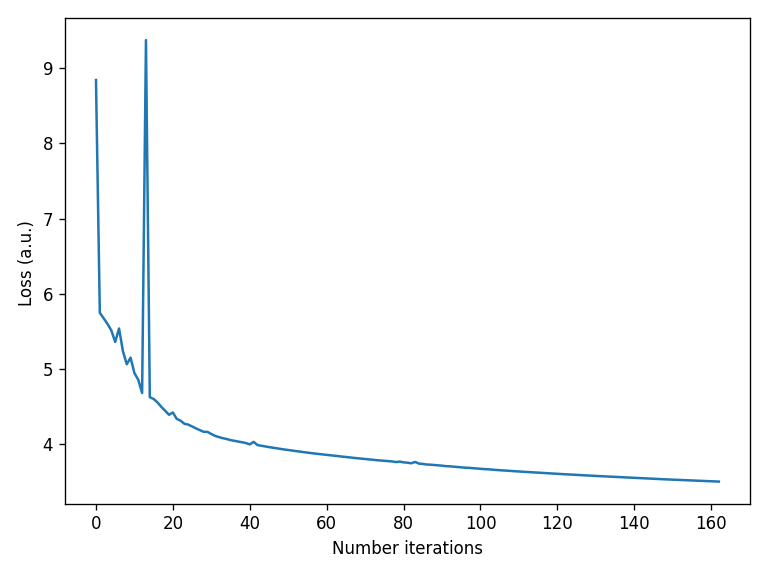

In [117]:
loss_vector = solution.loss_history 

plt.figure() 
plt.plot(loss_vector)
plt.xlabel("Number iterations")
plt.ylabel("Loss (a.u.) ")
plt.tight_layout() 

### Other optimizer algorithms 
By default the optimize function uses the 'trf' scipy algorithm. Here we exemplify 'dogbox' method as well. Other optimization algortihms can be used as well, namely all methods in scipy minimize, and 'adam' and 'rmsprop' from JAX' optax package. 

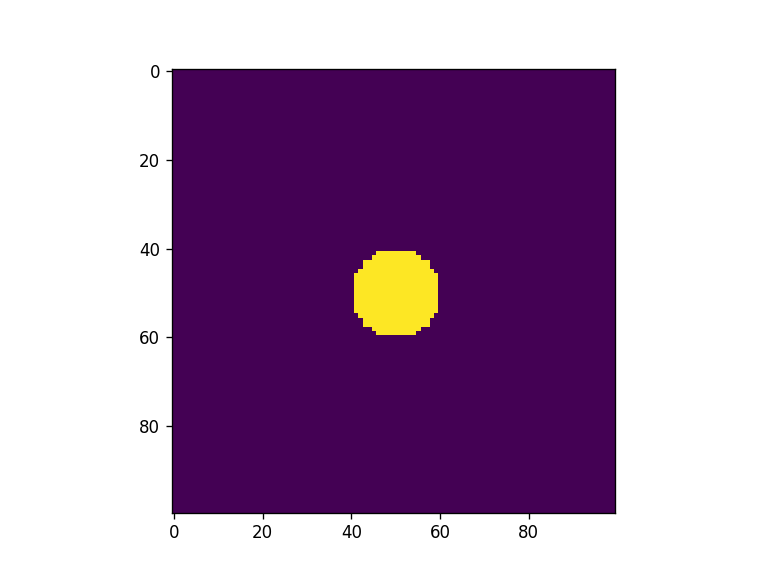

In [118]:
### Testing constant value initial guess 

#Initial guess
x0 = np.ones((x_pixel,y_pixel))
x0_flatten = x0.flatten()


#create target matrix (central cricular pattern) 
xi = np.arange(x_pixel)
yi = np.arange(y_pixel)
XX, YY = np.meshgrid(xi,yi)

target = np.zeros((x_pixel, y_pixel))
target[np.where(((XX-x_pixel/2)**2 + (YY-y_pixel/2)**2) < 10**2)] = 1 

target_flat = target.flatten()

fig = plt.figure() 
plt.imshow(target)

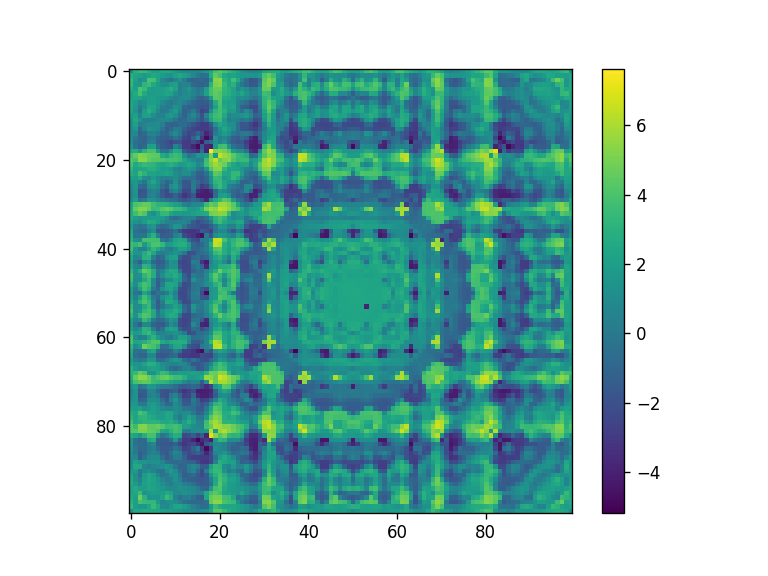

In [119]:
solution = moe.optimizer.optimize(logloss2, x0_flatten, args1=(aperture, screen, wavelength, target, "ASM", False), optimizer_method="dogbox", verbose=0, ftol=1e-5)

x = solution.x

fig = plt.figure() 
xar = np.reshape(x, (x_pixel, y_pixel))
plt.imshow(xar) 
plt.colorbar()

Elapsed: 0:00:00.016926
Elapsed: 0:00:00.015432
Elapsed: 0:00:00.021406


Text(0.5, 1.0, 'ASM propagation from optimized mask')

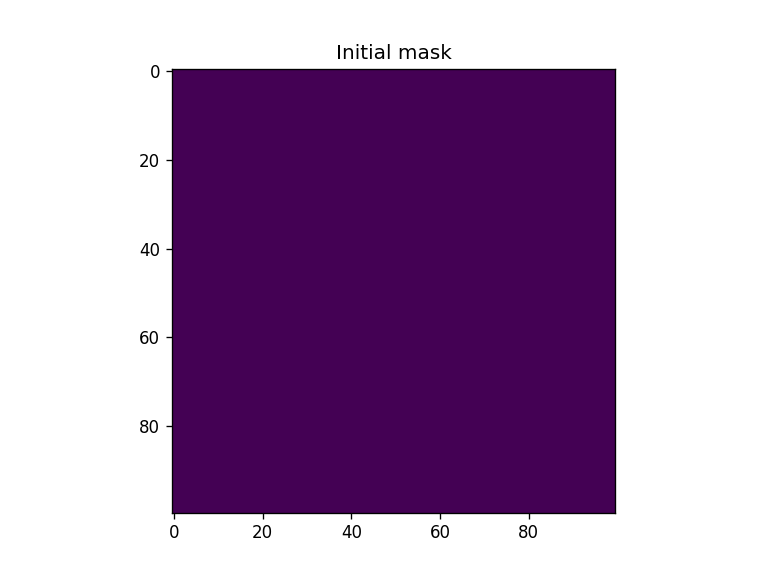

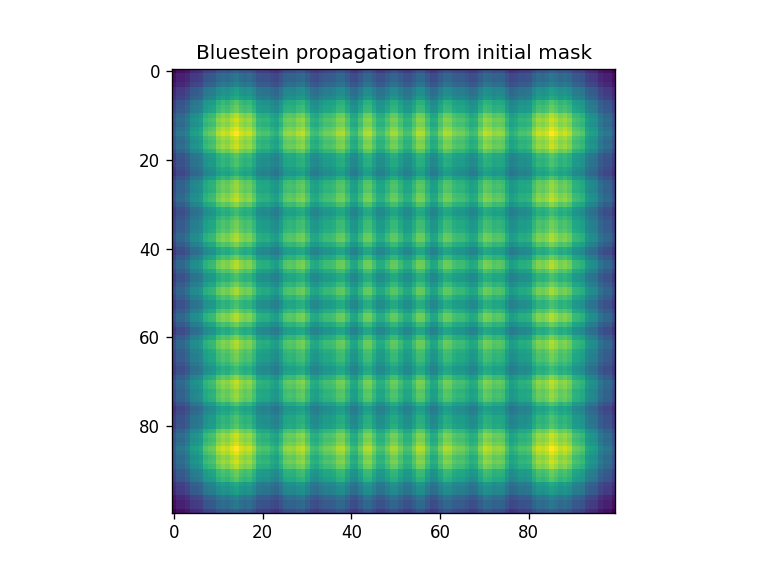

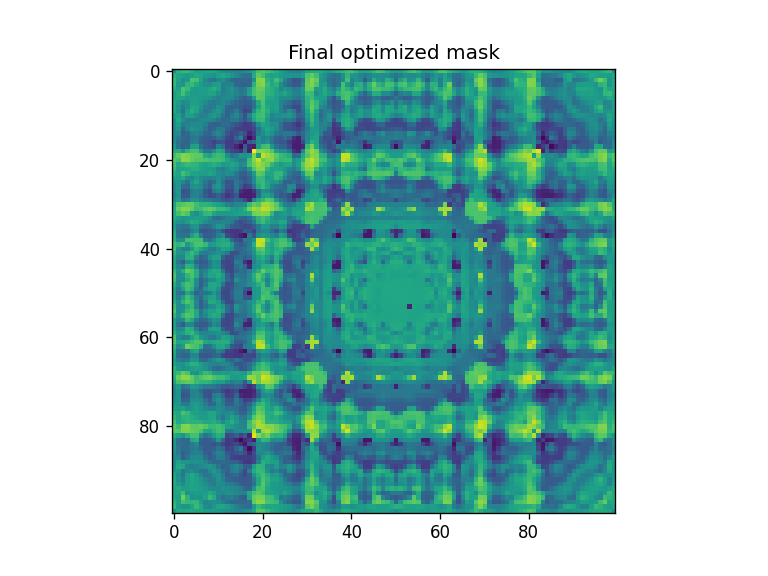

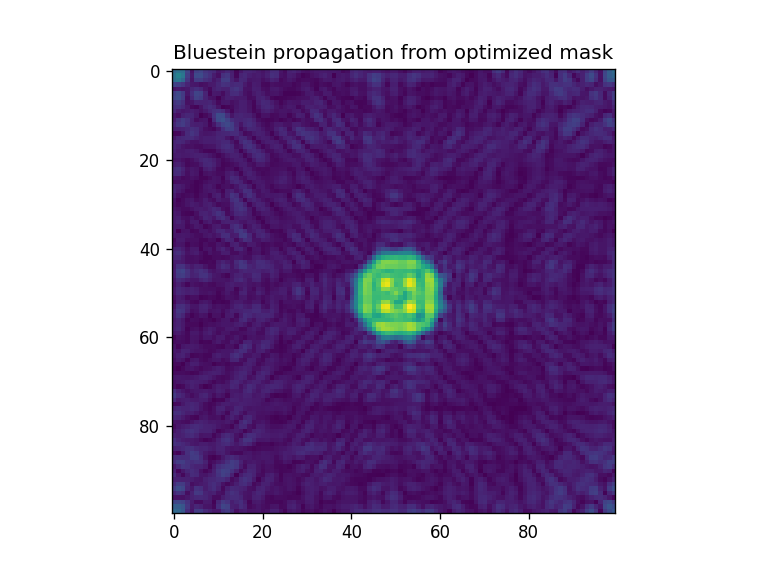

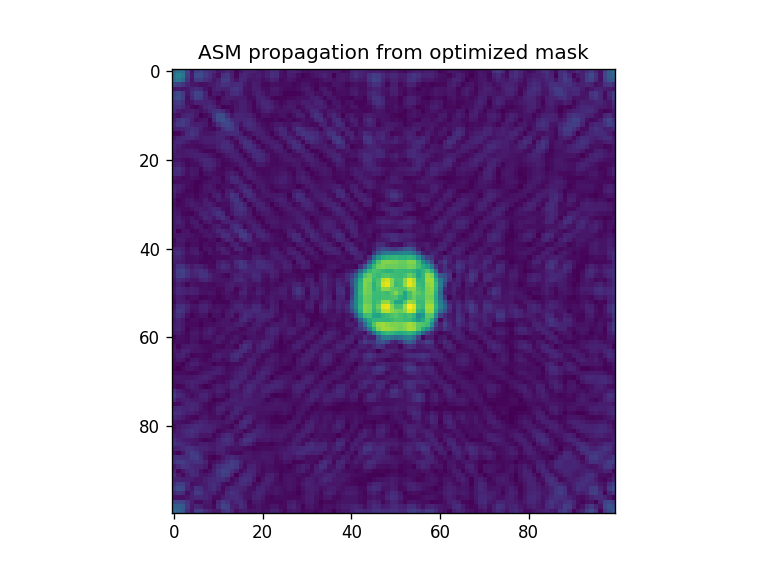

In [120]:
fig = plt.figure() 
xar2 = np.reshape(x0_flatten, (x_pixel, y_pixel))
plt.imshow(xar2) 
plt.title("Initial mask")

fig = plt.figure() 
plt.imshow(np.abs(moe.optimizer.propagate(xar2, aperture, screen, wavelength) ) )
plt.title("Bluestein propagation from initial mask")


fig = plt.figure() 
xar3 = np.reshape(x, (x_pixel, y_pixel))
plt.imshow(xar3) 
plt.title("Final optimized mask")

fig = plt.figure() 
plt.imshow(np.abs(moe.optimizer.propagate(xar3, aperture, screen, wavelength) ) )
plt.title("Bluestein propagation from optimized mask")

fig = plt.figure() 
plt.imshow(np.abs(moe.optimizer.propagate(xar3, aperture, screen, wavelength, "ASM") ) )
plt.title("ASM propagation from optimized mask")


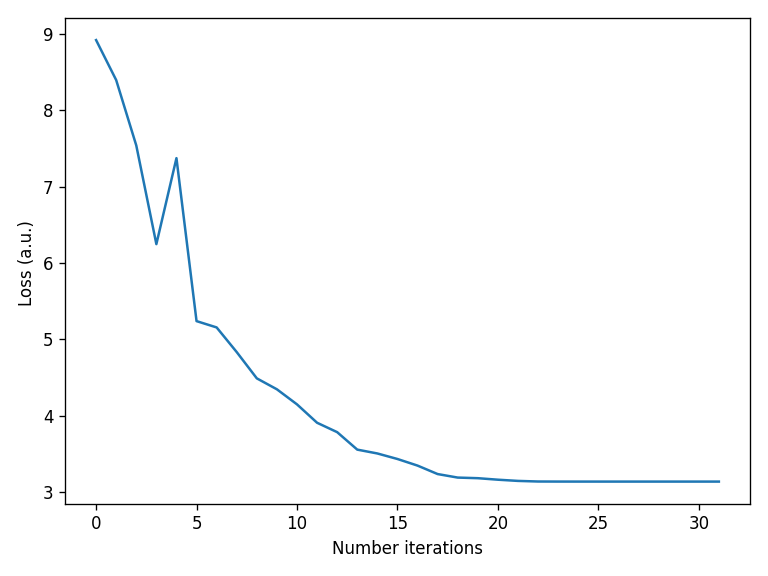

In [121]:
loss_vector = solution.loss_history 

plt.figure() 
plt.plot(loss_vector)
plt.xlabel("Number iterations")
plt.ylabel("Loss (a.u.) ")
plt.tight_layout() 

In [122]:
#Uncomment to try any of these global optimization methods 

##bounds = [(-np.pi, np.pi)]*len(x0_flatten)

#solution = moe.optimizer.optimize(logloss2, x0_flatten, args1=(aperture, screen,wavelength),  optimizer_method="dual_annealing", \
#                                  tol=1 , minimizer_kwargs={"args":(aperture, screen, wavelength), "tol": 1 },  bounds = bounds)

#solution = moe.optimizer.optimize(FOM2, x0_flatten, args1=(aperture, screen),  optimizer_method="basinhopping", tol=1 ,\
#                                  minimizer_kwargs={"args":(aperture, screen), "tol": 1 },  bounds = bounds)

#solution = moe.optimizer.optimize(FOM2, x0_flatten, args1=(aperture, screen),  optimizer_method="differential_evolution", tol=1 ,\
#                                  minimizer_kwargs={"args":(aperture, screen), "tol": 1 },  bounds = bounds)

#### Optimization with 'optax' module optimizers  

In [125]:
solution = moe.optimizer.optimize(logloss2, x0_flatten, args1=(aperture, screen, wavelength, target, "ASM", False), \
                                  optimizer_method="adam", verbose=0, ftol=1e-5)


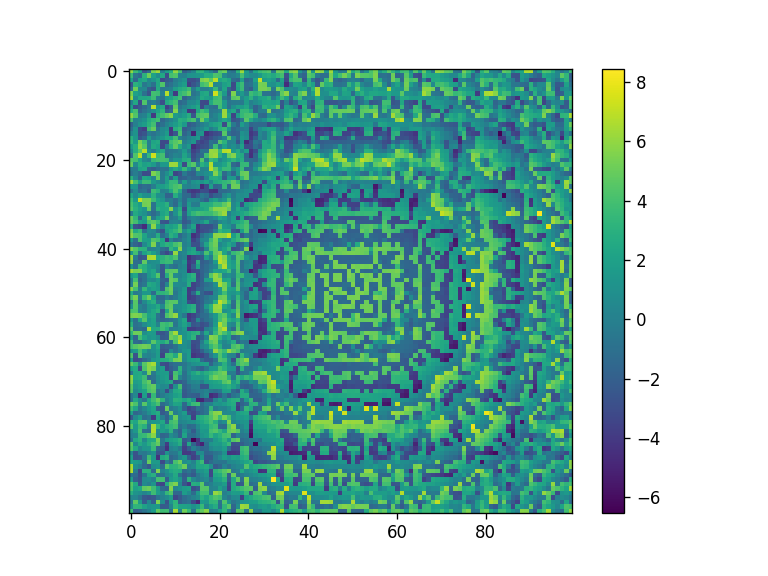

In [126]:
x = solution.x

fig = plt.figure() 
xar = np.reshape(x, (x_pixel, y_pixel))
plt.imshow(xar) 
plt.colorbar()

Elapsed: 0:00:00.015432
Elapsed: 0:00:00.016428
Elapsed: 0:00:00.015432


Text(0.5, 1.0, 'ASM propagation from optimized mask')

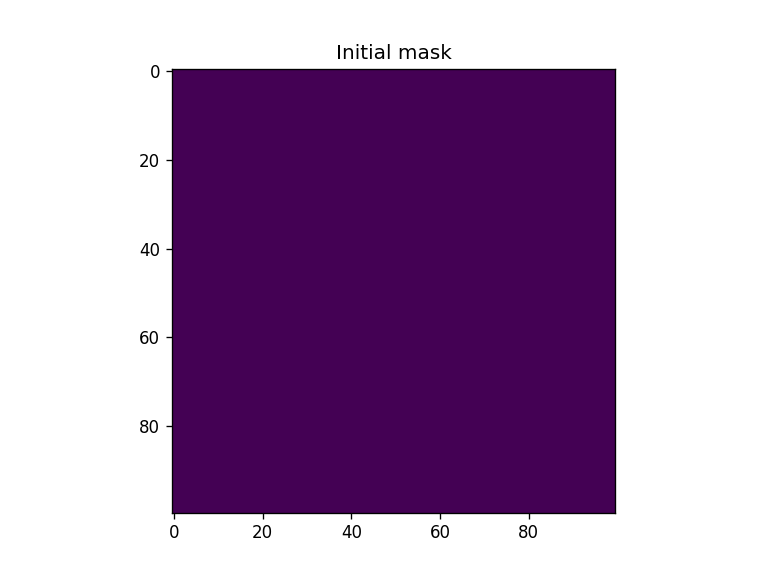

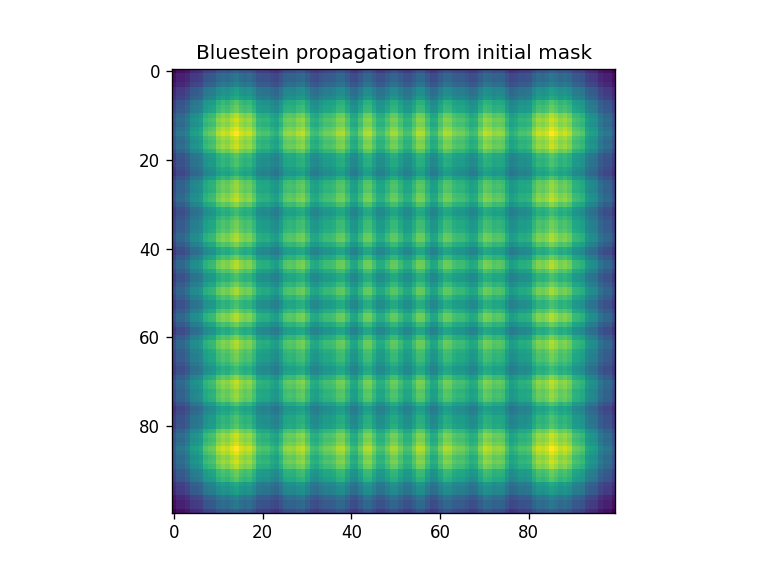

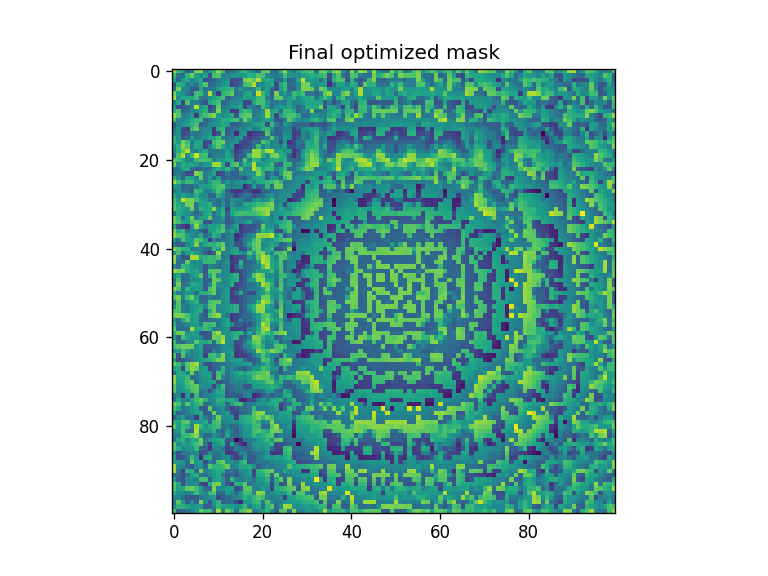

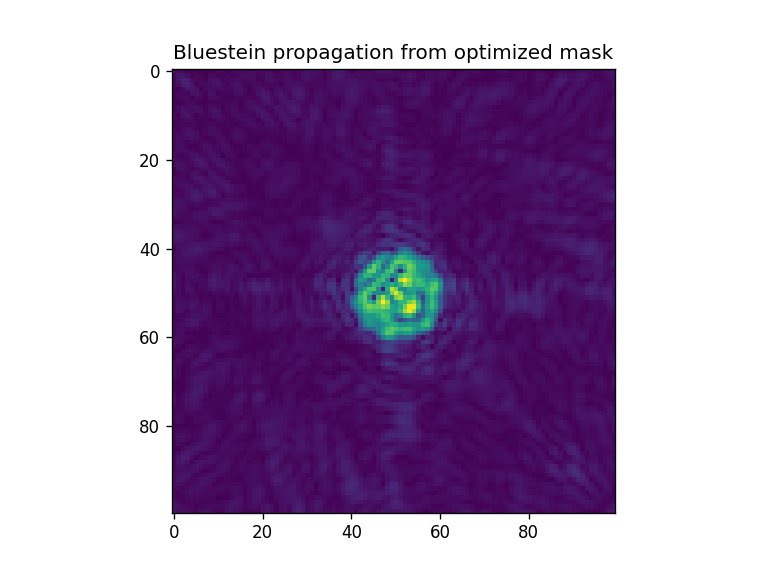

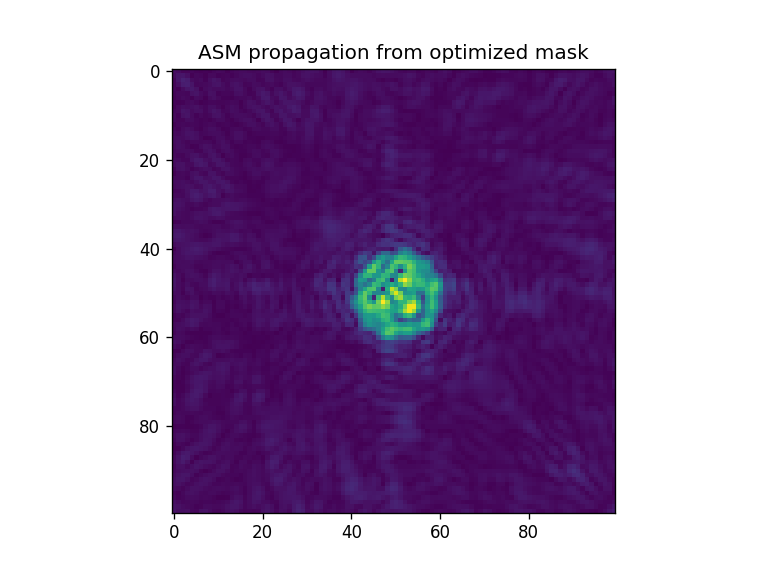

In [127]:
fig = plt.figure() 
xar2 = np.reshape(x0_flatten, (x_pixel, y_pixel))
plt.imshow(xar2) 
plt.title("Initial mask")

fig = plt.figure() 
plt.imshow(np.abs(moe.optimizer.propagate(xar2, aperture, screen, wavelength) ) )
plt.title("Bluestein propagation from initial mask")


fig = plt.figure() 
xar3 = np.reshape(x, (x_pixel, y_pixel))
plt.imshow(xar3) 
plt.title("Final optimized mask")

fig = plt.figure() 
plt.imshow(np.abs(moe.optimizer.propagate(xar3, aperture, screen, wavelength) ) )
plt.title("Bluestein propagation from optimized mask")

fig = plt.figure() 
plt.imshow(np.abs(moe.optimizer.propagate(xar3, aperture, screen, wavelength, "ASM") ) )
plt.title("ASM propagation from optimized mask")


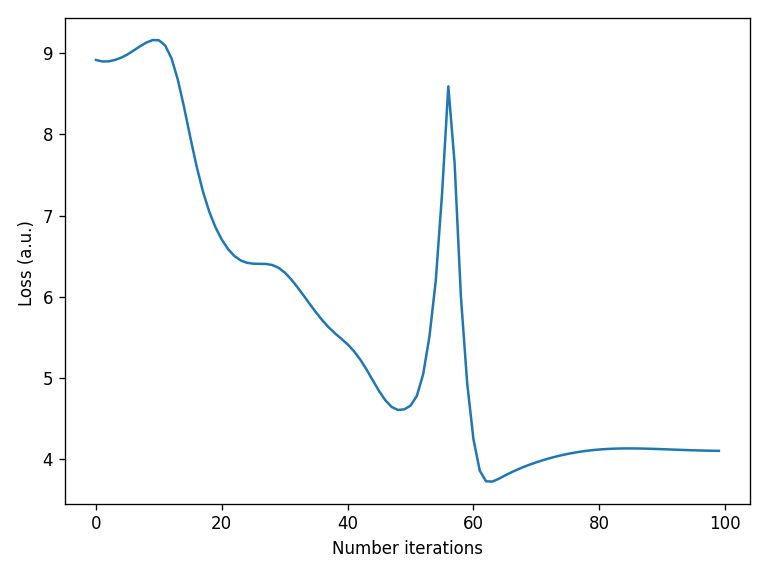

In [128]:
loss_vector = solution.loss_history 

plt.figure() 
plt.plot(loss_vector)
plt.xlabel("Number iterations")
plt.ylabel("Loss (a.u.) ")
plt.tight_layout() 

### Bounds during optimization  
By default the optimizers are unbound. Some can be bound, such as 'dogbox'.  

Elapsed: 0:00:00.015432
Elapsed: 0:00:00.014436
Elapsed: 0:00:00.040323
Elapsed: 0:00:00.014933
Elapsed: 0:00:00.014436
Elapsed: 0:00:00.039328
Elapsed: 0:00:00.014931
Elapsed: 0:00:00.014437
Elapsed: 0:00:00.040323
Elapsed: 0:00:00.014934
Elapsed: 0:00:00.016926
Elapsed: 0:00:00.038331
Elapsed: 0:00:00.017424
Elapsed: 0:00:00.014934
Elapsed: 0:00:00.039328
Elapsed: 0:00:00.014437
Elapsed: 0:00:00.013939
Elapsed: 0:00:00.039327
Elapsed: 0:00:00.014436
Elapsed: 0:00:00.014437
Elapsed: 0:00:00.047292
Elapsed: 0:00:00.019415
Elapsed: 0:00:00.018418
Elapsed: 0:00:00.041318
Elapsed: 0:00:00.014436
Elapsed: 0:00:00.013939
Elapsed: 0:00:00.466954
Elapsed: 0:00:00.016924
Elapsed: 0:00:00.018918
Elapsed: 0:00:00.039327
Elapsed: 0:00:00.014935
Elapsed: 0:00:00.014436
Elapsed: 0:00:00.041318
Elapsed: 0:00:00.014436
Elapsed: 0:00:00.014437
Elapsed: 0:00:00.044305
Elapsed: 0:00:00.014914
Elapsed: 0:00:00.017423
Elapsed: 0:00:00.053786
Elapsed: 0:00:00.014934
Elapsed: 0:00:00.014935
Elapsed: 0:00:00

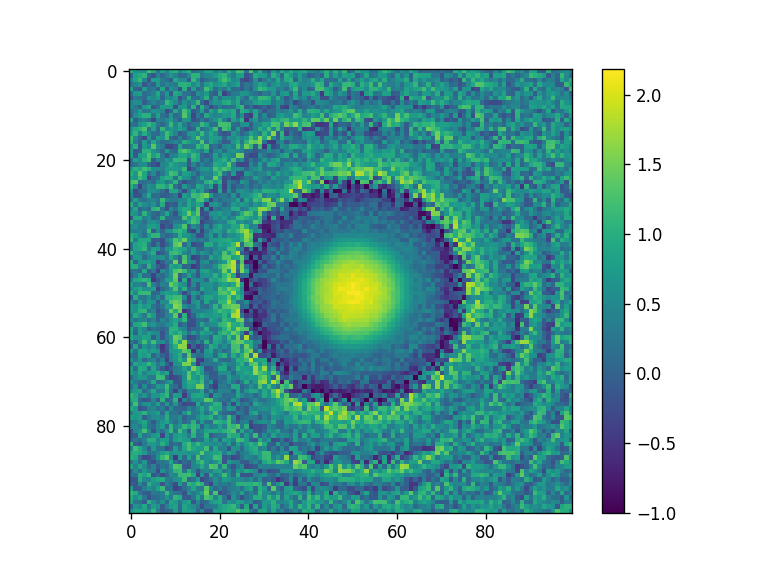

In [135]:
## Optimization with bounds 

solution = moe.optimizer.optimize(mseloss, x0_flatten, args1=(aperture, screen, wavelength, target, "bluestein",), optimizer_method="dogbox", \
                                  bounds =(-1, 3), ftol = 1e-12 ,xtol=1e-12, )

x = solution.x

fig = plt.figure() 
xar = np.reshape(x, (x_pixel, y_pixel))
plt.imshow(xar) 
plt.colorbar()

Elapsed: 0:00:00.027382


Text(0.5, 1.0, 'Bluestein propagation from optimized mask')

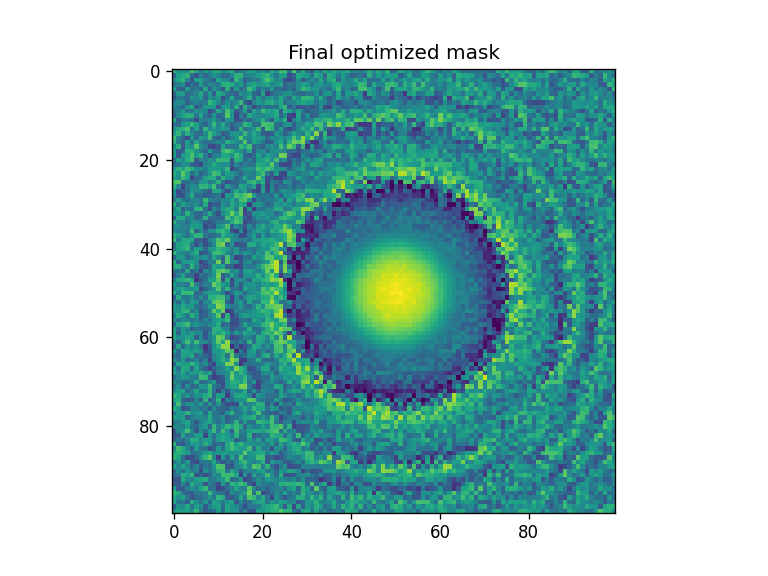

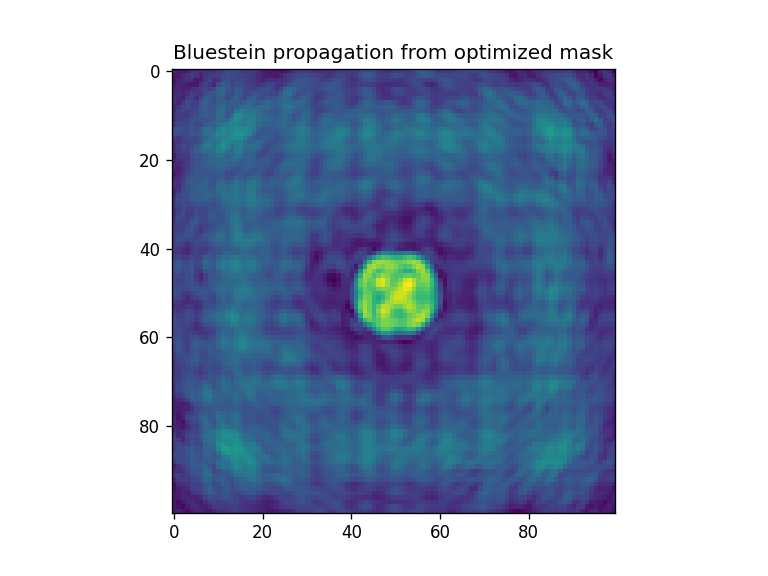

In [136]:
fig = plt.figure() 
xar3 = np.reshape(x, (x_pixel, y_pixel))
plt.imshow(xar3) 
plt.title("Final optimized mask")

fig = plt.figure() 
plt.imshow(np.abs(moe.optimizer.propagate(xar3, aperture, screen, wavelength) ) )
plt.title("Bluestein propagation from optimized mask")


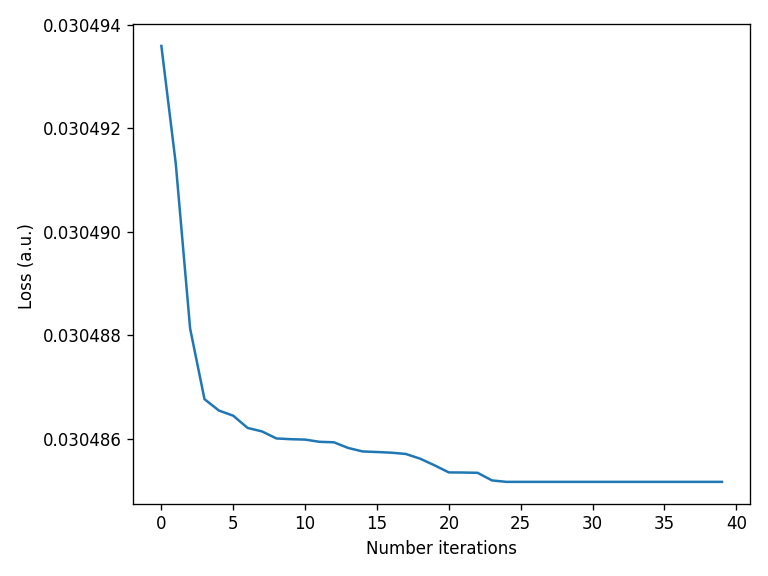

In [137]:
loss_vector = solution.loss_history 

plt.figure() 
plt.plot(loss_vector)
plt.xlabel("Number iterations")
plt.ylabel("Loss (a.u.) ")
plt.tight_layout() 

## Hologram creation via inverse design

(1024, 1024)

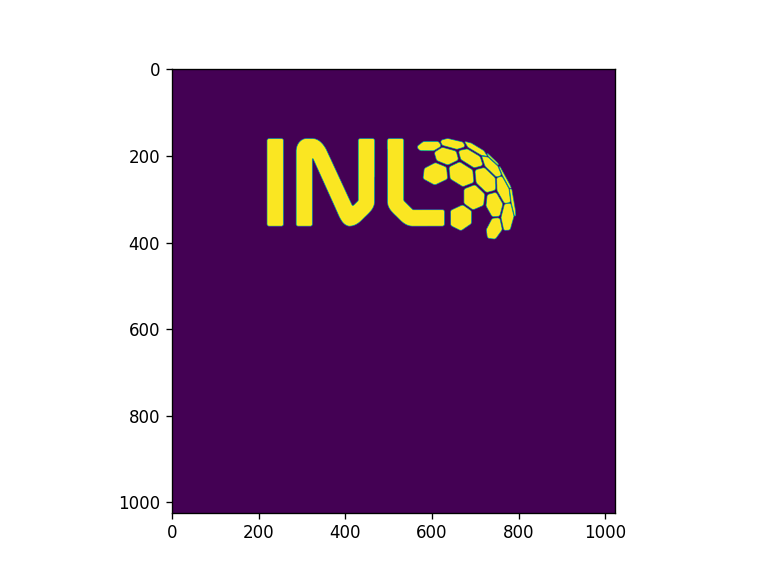

In [175]:
file = "../5 - Holograms/target.png"
targetread = plt.imread(file)

x_pixel, y_pixel = np.shape(targetread)

xi = np.arange(x_pixel)
yi = np.arange(y_pixel)
XX, YY = np.meshgrid(xi,yi, indexing = 'ij')
    

fig = plt.figure() 
plt.imshow(targetread)

targetread.shape

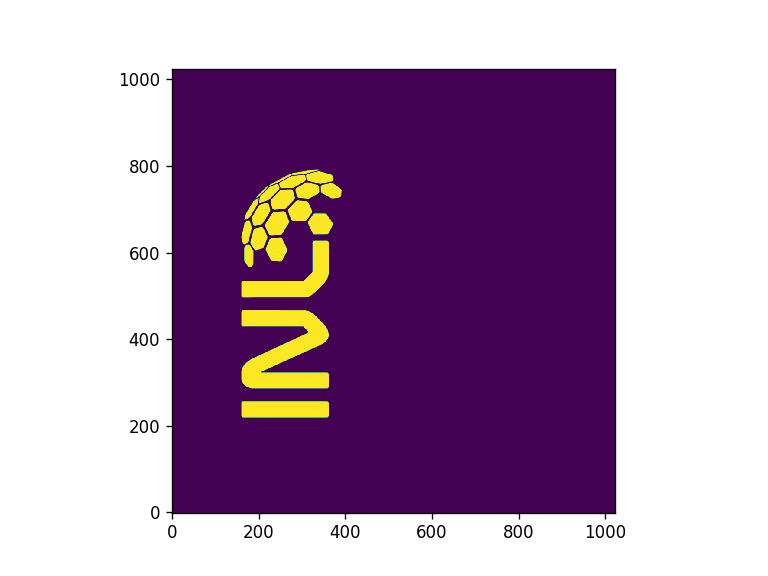

In [176]:
fig = plt.figure() 
plt.pcolormesh(XX,YY,targetread)
plt.gca().set_aspect('equal')

**IMPORTANT** the target is read as represented in the pcolormesh above in the ij indexing convention (used throughout the calculations). Hence, to have the correct representation, the axes need to be transformed.  

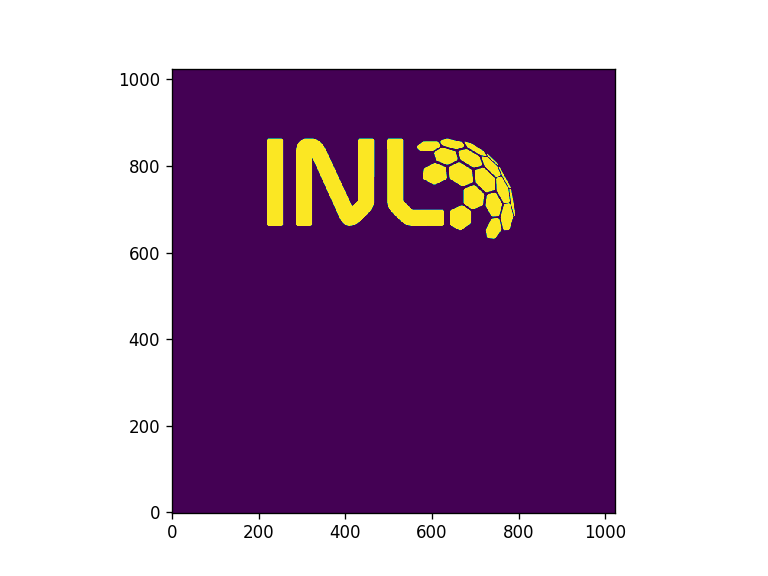

In [177]:
target = np.flip(np.rot90(targetread))

#OR THIS ONE
#targetread = np.flipud(targetread)
#targetread = np.swapaxes(targetread, 0,1)

fig = plt.figure() 
plt.pcolormesh(XX,YY,target)
plt.gca().set_aspect('equal')

In [178]:
#Place holders for apertures 

#size of the rectangular mask 
aperture_width  = 50e-6 #m
aperture_height = 50e-6

pixsize = 1e-6 #m

wavelength = 500e-9 #m
focal_length = 200e-6

zmin = wavelength
zmax = 1.2* focal_length
nzs = 500

radius = aperture_width/2 

# Create Aperture
aperture1 = moe.generate.create_empty_aperture(-aperture_width/2, aperture_width/2, x_pixel, -aperture_height/2, aperture_height/2, y_pixel)


In [179]:
#Define Screen 

# define the wavelength used in the propagation
wavelength = 532*nano

# Define the screen size and create it

screen_width = 2.5
screen_height = 2.5
x_pixel = 1024
y_pixel = 1024


# Creates a screen in YZ plane with [-aperture_height/2, aperture_height/2] and [zmin, zmax] and 
ymin, ymax = -screen_height/2, screen_height/2
xmin, xmax = -screen_width/2, screen_width/2 

s = 0.2 

x = np.linspace(xmin*s, xmax*s, x_pixel)
y = np.linspace(ymin*s, ymax*s, y_pixel)
z = np.array([ s ])


screen = moe.Screen(x,y,z)

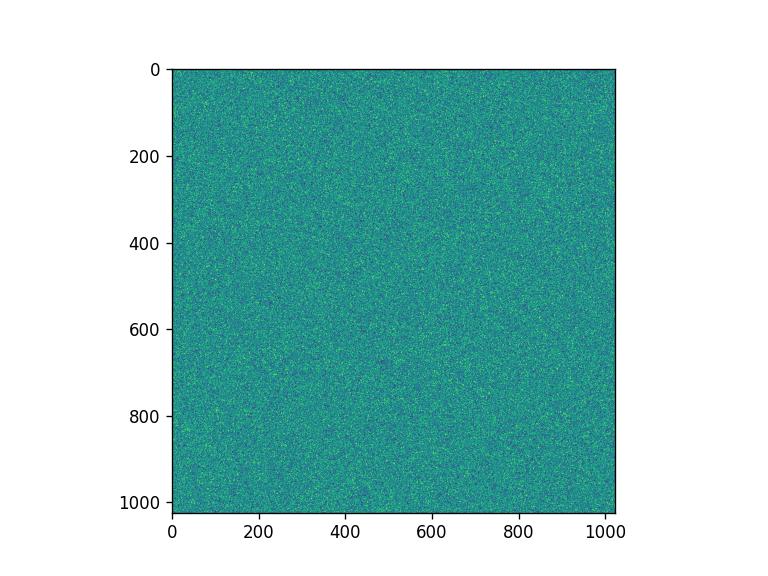

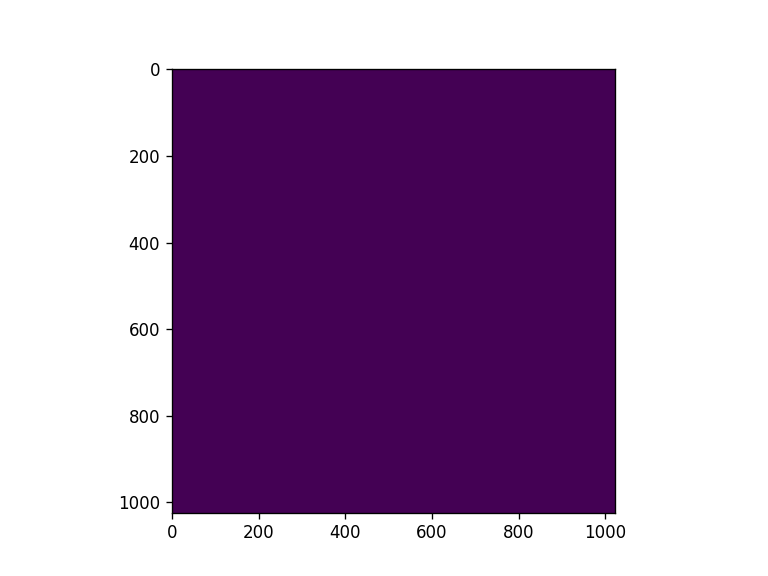

In [180]:
# generation of initial guesses, 

#random 
xrand = np.random.rand(x_pixel, y_pixel)

plt.figure() 
plt.imshow(xrand)

#constant 
xvalues = np.ones((x_pixel, y_pixel))

plt.figure()
plt.imshow(xvalues)
#plt.colorbar()

In [181]:
def mselossmax(x, mask, screen, wavelength, target, use_timer=True, propag="bluestein", pad=2): 
    import jax.numpy as jnp 
    
    prop_x =  jnp.abs(moe.optimizer.propagate(jnp.reshape(x, (len(screen.x), len(screen.y))), mask, screen, wavelength,\
                                             propagation_method=propag, pad_factor=pad, use_timer=use_timer))**2

    diff = jnp.abs(prop_x/jnp.max(prop_x) - target/jnp.max(target))**2
     
    res = jnp.sum(diff)
    return res

In [182]:
solution = moe.optimizer.optimize(mselossmax, x0= xvalues.flatten(), args1=[aperture1, screen, wavelength, target, False], verbose = 1, ftol=1e-6, xtol=None,\
                                  optimizer_method='dogbox', )


x2 = solution.x


`ftol` termination condition is satisfied.
Function evaluations 88, initial cost 1.8666e+09, final cost 3.8342e+08, first-order optimality 2.55e+03.


Elapsed: 0:00:00.585929


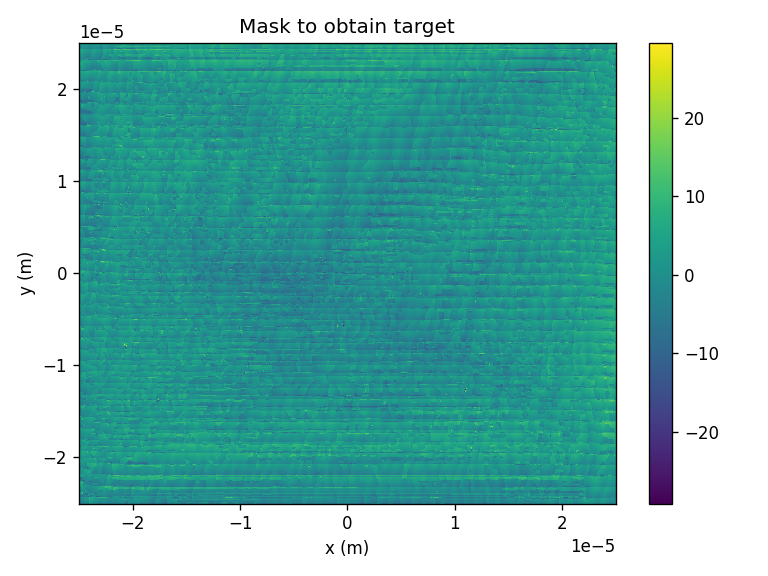

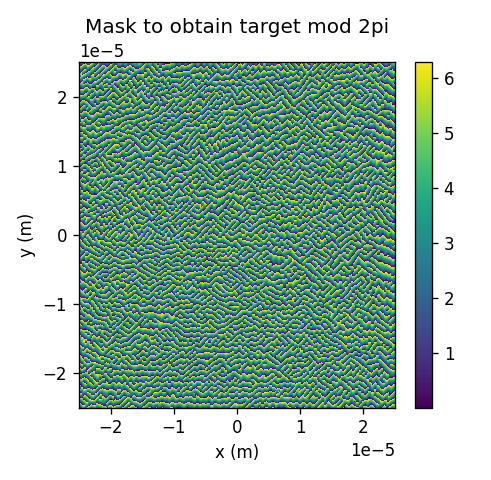

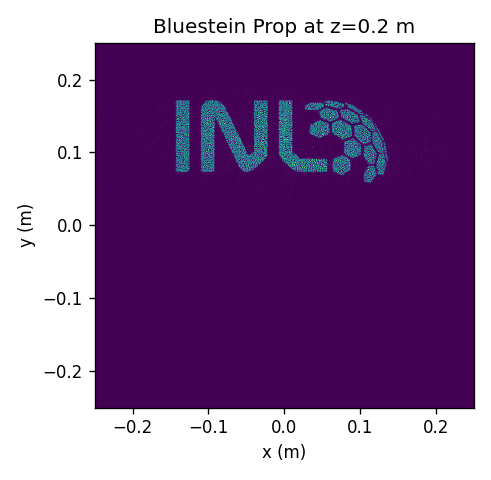

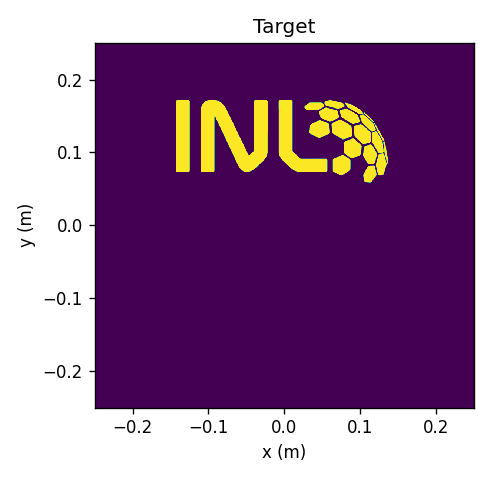

In [183]:
xar3 = (np.reshape(x2, (x_pixel, y_pixel)))

# Create Aperture
aperture1 = moe.generate.create_empty_aperture(-aperture_width/2, aperture_width/2, x_pixel, -aperture_height/2, aperture_height/2, y_pixel)

fig = plt.figure() 

plt.pcolormesh(aperture1.XX, aperture1.YY, xar3) 
plt.title("Mask to obtain target")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.colorbar()
plt.tight_layout()

fig = plt.figure(figsize=(4.1,4)) 
plt.pcolormesh(aperture1.XX, aperture1.YY, (xar3)%(2*np.pi) )
plt.title("Mask to obtain target mod 2pi")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.colorbar()
plt.tight_layout()

fig = plt.figure(figsize=(4.1,4)) 
plt.pcolormesh(screen.XX[:,:,-1], screen.YY[:,:,-1], np.abs(moe.optimizer.propagate(xar3, aperture1, screen, wavelength) )**2 )
#plt.imshow(np.abs(moe.optimizer.propagate(xar3, aperture1, screen, wavelength) )**2 )
plt.title("Bluestein Prop at z="+str(screen.z[-1])+" m")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.tight_layout()

fig = plt.figure(figsize=(4.1,4)) 
plt.pcolormesh(screen.XX[:,:,-1], screen.YY[:,:,-1], (np.reshape(target, (x_pixel, y_pixel)) )) 
#plt.imshow(target)
plt.title("Target")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.tight_layout()

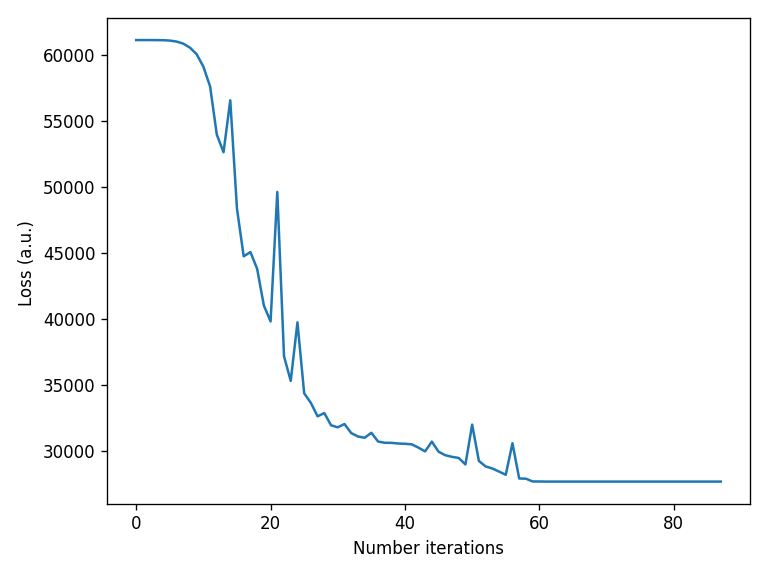

In [184]:
loss_vector = solution.loss_history 

plt.figure() 
plt.plot(loss_vector)
plt.xlabel("Number iterations")
plt.ylabel("Loss (a.u.) ")
plt.tight_layout() 

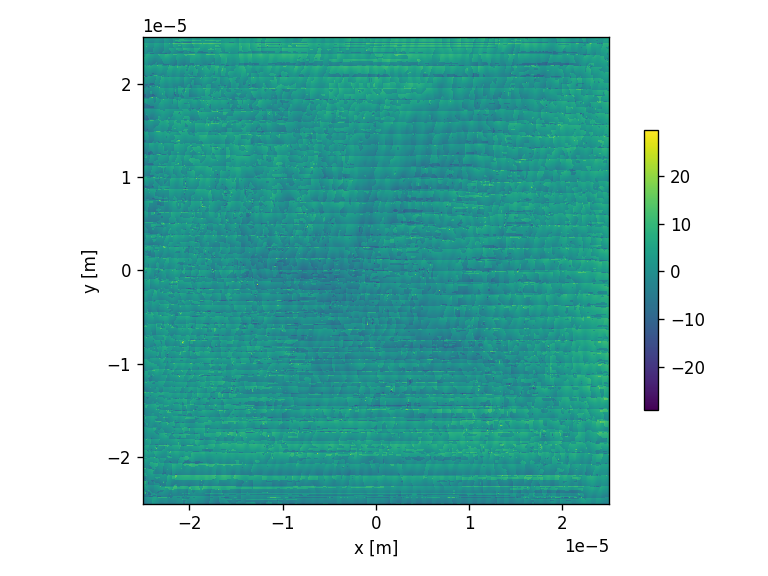

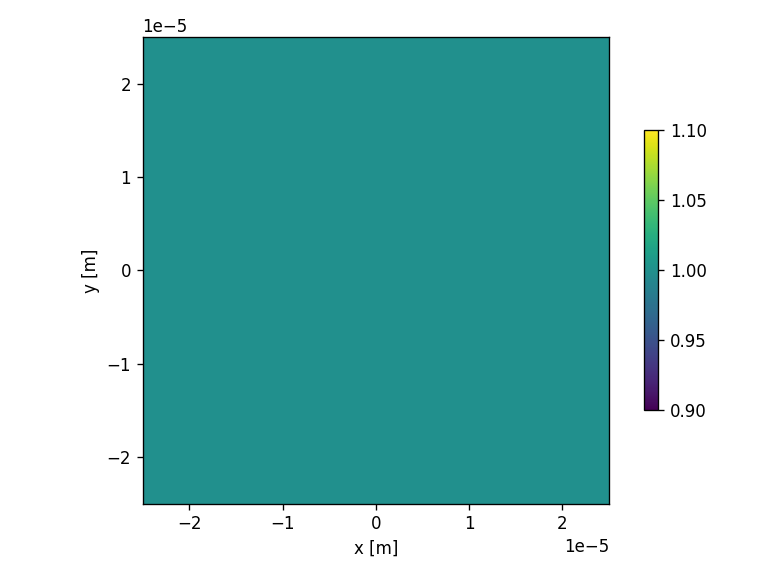

Progress: [####################] 100.0%
Elapsed: 0:00:00.941867


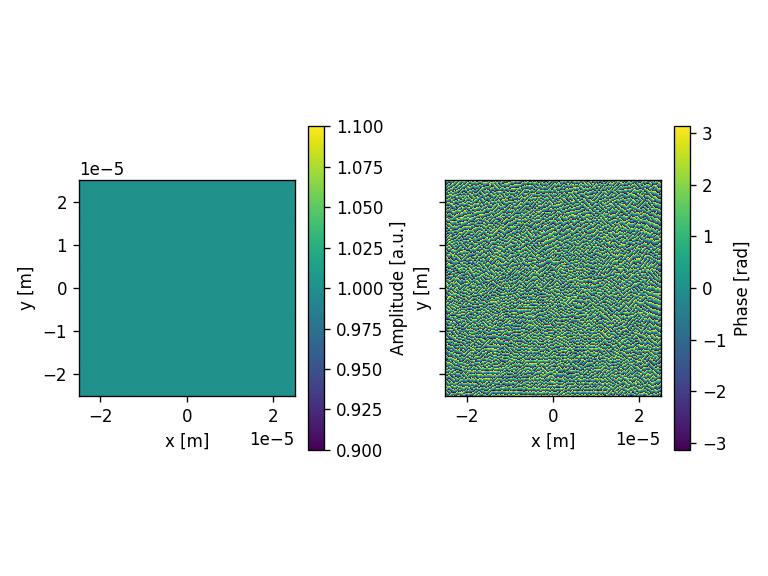

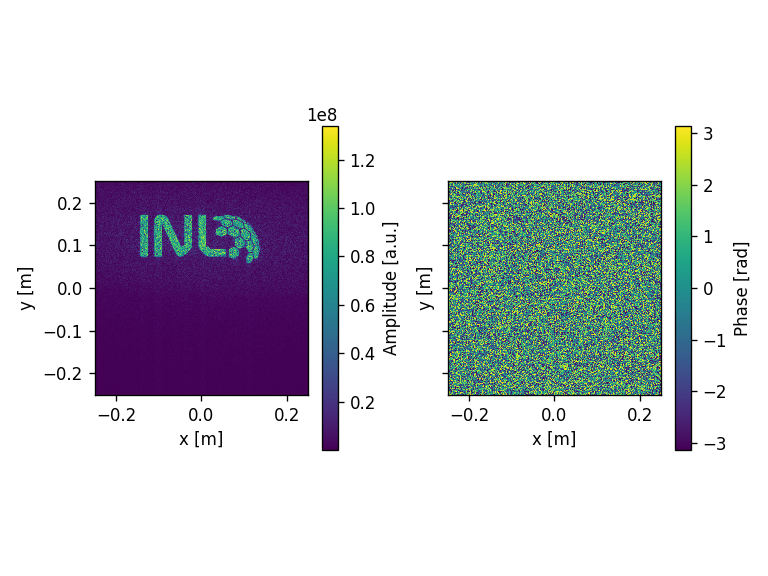

In [185]:
screen = moe.Screen(x,y,z)

# Define Aperture
aperture = moe.generate.create_empty_aperture(-aperture_width/2, aperture_width/2, x_pixel, -aperture_height/2, aperture_height/2, y_pixel)
mask_amplitude = moe.generate.create_empty_aperture_from_aperture(aperture)

# Define Phase mask 
mask_phase = moe.generate.create_empty_aperture_from_aperture(aperture)
mask_phase.aperture = xar3 

#mask_phase.aperture =  np.flipud(np.rot90(xar3)) ##use need to 

mask_amplitude.aperture = mask_amplitude.aperture +1 

# Plot the circular mask
moe.plotting.plot_aperture(mask_phase)
moe.plotting.plot_aperture(mask_amplitude)

# Calculates a field to use with the calculated mask

# Initialize a Field from the Aperture mask 
field = moe.field.create_empty_field_from_aperture(mask_phase)
# Generate a uniform field
field = moe.field.generate_uniform_field(field, E0=1)


# Modulates the field with a given aperture that can be used either as an amplitude mask or a phase mask
field = moe.field.modulate_field(field, amplitude_mask=mask_amplitude, phase_mask=mask_phase)
# Plots the field (amplitude and phase)
moe.plotting.plot_field(field)


# Propagate the field with Bluestein 
EXYZ = moe.propagate.Bluestein(field, screen, wavelength)
moe.plotting.plot_screen_XY(EXYZ, z=s)

AGAIN, **BEWARE all imshow will show rotated+flipped matrices, e.g. the optimization result shown below appers flipped and rotated**!!! 

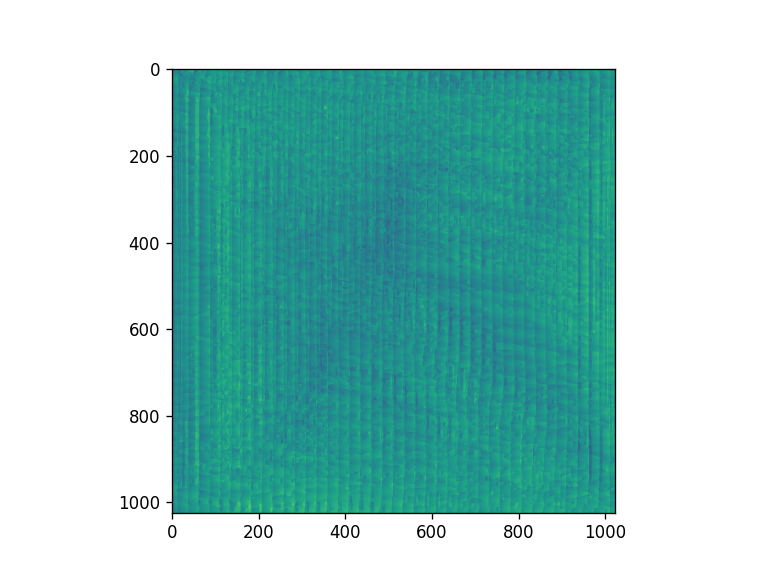

In [186]:
plt.figure() 
plt.imshow(xar3)

## Optimization of ensembles of optical elements 

In [187]:
###Import two surfaces - doublet 

#number of pixels 
x_pixel = 100
y_pixel = 100

a1_phase = np.random.rand(x_pixel, y_pixel) #np.genfromtxt("asph1_phase.csv", delimiter=',')
a1_inten = a1_phase * 0 #np.genfromtxt("asph1_inten.csv", delimiter=',')

a2_phase = np.random.rand(x_pixel, y_pixel) #np.genfromtxt("asph2_phase.csv", delimiter=',')
a2_inten = a2_phase * 0 #np.genfromtxt("asph2_inten.csv", delimiter=',')



#size of the rectangular mask 
aperture_width  = 800e-6 #m
aperture_height = 800e-6

pixsize = 8e-6 #m

wavelength = 550e-9 

dist1 = 40e-3 
dist2 = 50e-3

zmin1 = wavelength
zmax1 = dist1
nzs = 2

zmin2 = wavelength
zmax2 = dist2
nzs = 2

radius = aperture_width/2 


asph1_mask_phase = moe.generate.create_empty_aperture(-aperture_width/2, aperture_width/2, x_pixel, -aperture_height/2, aperture_height/2, y_pixel)
asph1_mask_phase.aperture = a1_phase

asph1_mask_inten = moe.generate.create_empty_aperture_from_aperture(asph1_mask_phase)
asph1_mask_inten.aperture = a1_inten

asph2_mask_phase = moe.generate.create_empty_aperture(-aperture_width/2, aperture_width/2, x_pixel, -aperture_height/2, aperture_height/2, y_pixel)
asph2_mask_phase.aperture = a2_phase

asph2_mask_inten = moe.generate.create_empty_aperture_from_aperture(asph2_mask_phase)
asph2_mask_inten.aperture = a2_inten

aperture = moe.generate.create_empty_aperture_from_aperture(asph2_mask_phase)
mask = moe.generate.circular_aperture(aperture, radius=radius*10)

aperture_array_phase = [asph1_mask_phase, asph2_mask_phase]
aperture_array_amp = [mask,]*len(aperture_array_phase)

############################
## Define the screens 
x1 = asph1_mask_phase.x
y1 = asph1_mask_phase.y
z1 = np.linspace(zmin1, zmax1, nzs)

screen1 = moe.field.Screen(x1,y1,z1)

x2 = asph2_mask_phase.x
y2 = asph2_mask_phase.y
z2 = np.linspace(zmin2, zmax2, nzs)

screen2 = moe.field.Screen(x2,y2,z2)


screen_array = [screen1, screen2]

##################################
#Wavelengths 
wavelength_array = [wavelength]

###############################
#input field 

field_input = moe.field.create_empty_field_from_aperture(aperture)
field_input = moe.field.generate_uniform_field(field_input, E0=1)
input_light_field = field_input

##create ensemble 
ensemble = moe.ensemble.Ensemble(aperture_array_amp, aperture_array_phase, screen_array,  wavelength_array, input_light_field)

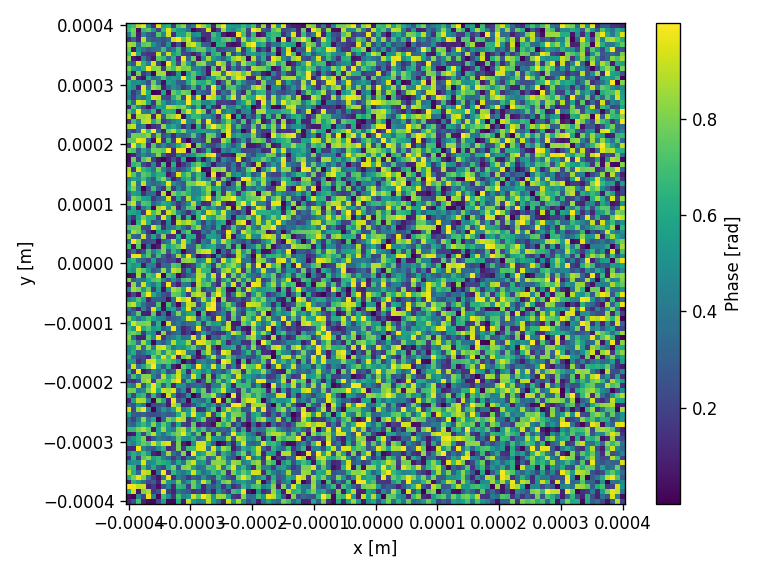

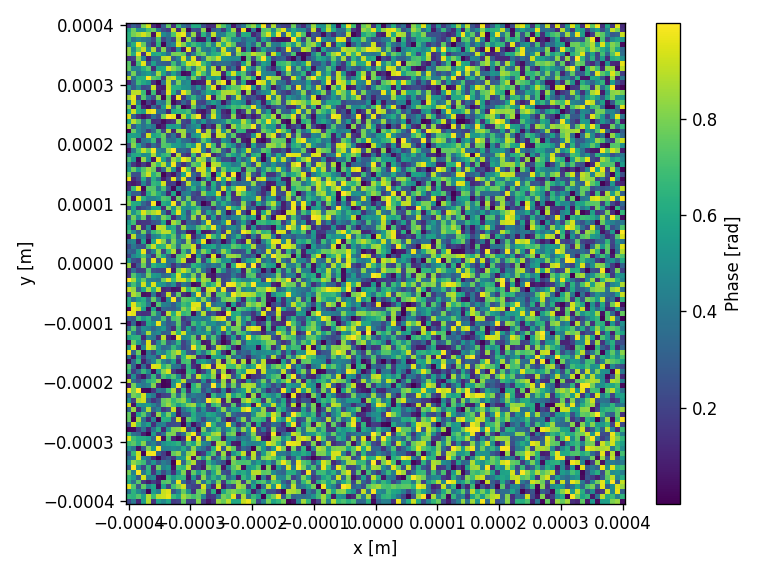

In [188]:
#the initial arrays are two random matrices represented below 

fig = plt.figure() 
plt.pcolormesh(aperture_array_phase[0].XX, aperture_array_phase[0].YY, aperture_array_phase[0].aperture)
plt.colorbar(label ="Phase [rad]")
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.tight_layout()

fig = plt.figure() 
plt.pcolormesh(aperture_array_phase[1].XX, aperture_array_phase[1].YY, aperture_array_phase[1].aperture)
plt.colorbar(label ="Phase [rad]")
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.tight_layout() 

Surface #1
Progress: [####################] 100.0%
Elapsed: 0:00:00.009459
Surface #2
Progress: [####################] 100.0%
Elapsed: 0:00:00.018420


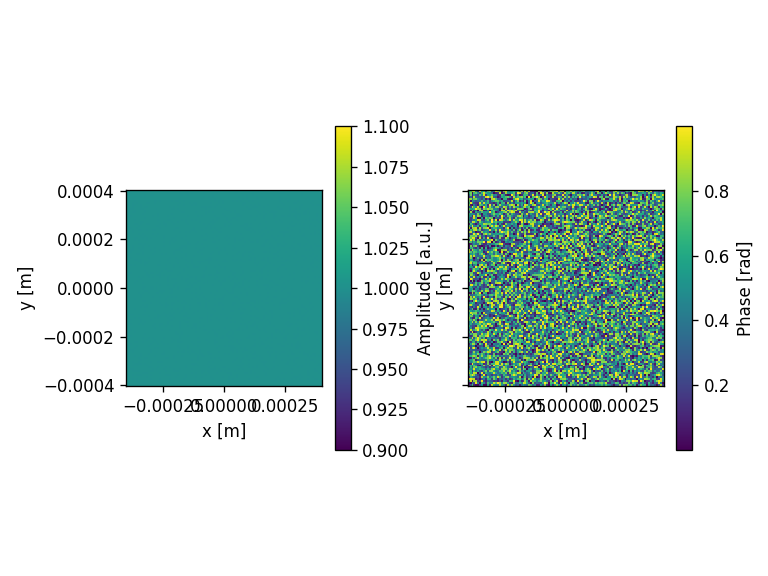

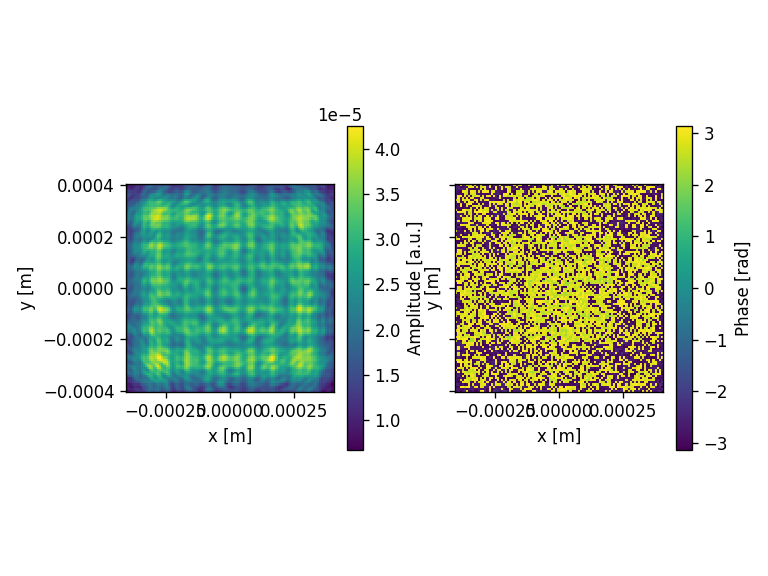

In [189]:
prop_methods = ["bluestein", "bluestein"]
EXY_array2 = [moe.propagate.propagate_through_ensemble(ensemble, wavelength, propagation_methods_array=prop_methods) for wavelength in wavelength_array]

In [190]:
x0_flatten = (np.array([aperture_array_phase[0].aperture.flatten(), aperture_array_phase[1].aperture.flatten()]) ).flatten()
x0_flatten.shape, a1_phase.shape 

((20000,), (100, 100))

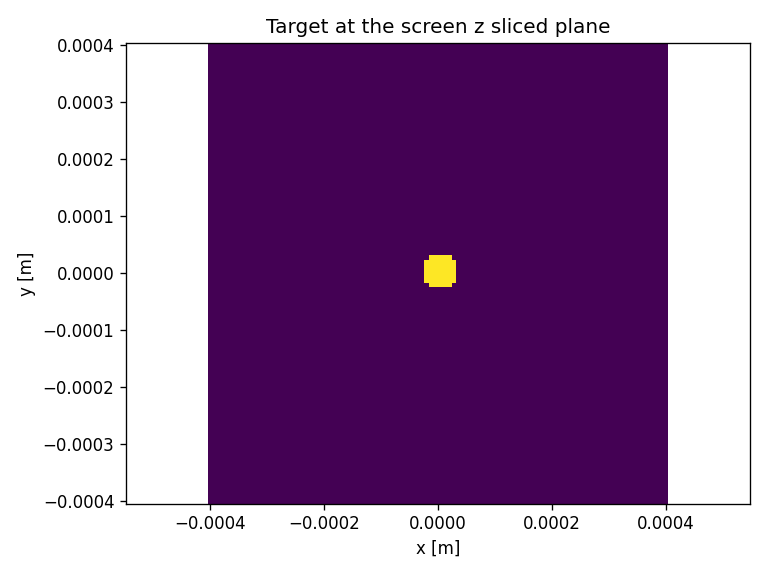

In [191]:
xi = np.arange(x_pixel)
yi = np.arange(y_pixel)
XX, YY = np.meshgrid(xi,yi, indexing='ij')
    
target = np.zeros((x_pixel, y_pixel))
target[np.where(((XX-x_pixel/2- 0)**2 + (YY-y_pixel/2-0)**2) < 4**2)] = 1 

target_flat = target.flatten()

fig = plt.figure() 
plt.pcolormesh(screen_array[-1].XX[:,:,-1], screen_array[-1].YY[:,:,-1], target )
plt.axis("equal")
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title("Target at the screen z sliced plane")
plt.tight_layout() 

In [192]:
def loss(x, mask, screen_array, wavelength, target, use_timer=True, propag="bluestein"): 
    import jax.numpy as jnp 
    
    #prop_x =  np.abs(moe.optimizer.propagate(np.reshape(x, (len(screen.x), len(screen.y))), mask, screen, wavelength, propagation_method=propag))
    xar1 = jnp.reshape(x[0:int(len(x)/2)], (len(screen_array[0].x), len(screen_array[0].y)))
    xar2 = jnp.reshape(x[int(len(x)/2):], (len(screen_array[0].x), len(screen_array[0].y)))
    xar=[xar1, xar2]
    
    prop_x = moe.optimizer.propagate(xar, aperture=aperture_array_phase, screen=screen_array , wavelength=wavelength_array, \
          mask_amp = aperture_array_amp, circ_radius=None, input_field="uniform", E0=1, \
          propagation_method=["ASM","ASM"], pad_factor=2, modedef = "czt", ensemble_mode=True , corr=1e5, use_timer=use_timer  )**2
    
    
    diff = jnp.abs(prop_x/jnp.sum(prop_x) - target/jnp.max(target))**2
     
    res = np.sum(diff)

    return res

In [193]:
solution = moe.optimizer.optimize(loss, x0_flatten, args1=[aperture, screen_array, wavelength, target, False], verbose = 1, ftol=1e-4,)

x = solution.x

Elapsed: 0:00:00.073677
Elapsed: 0:00:00.061729
Elapsed: 0:00:00.078655
Elapsed: 0:00:00.063719
Elapsed: 0:00:00.139389
Elapsed: 0:00:00.139389
Elapsed: 0:00:00.062723
Elapsed: 0:00:00.064716
Elapsed: 0:00:00.060235
Elapsed: 0:00:00.059242
Elapsed: 0:00:00.115987
Elapsed: 0:00:00.112510
Elapsed: 0:00:00.048783
Elapsed: 0:00:00.048786
Elapsed: 0:00:00.069694
Elapsed: 0:00:00.044307
Elapsed: 0:00:00.068698
Elapsed: 0:00:00.065713
Elapsed: 0:00:00.066707
Elapsed: 0:00:00.061729
Elapsed: 0:00:00.115490
Elapsed: 0:00:00.116988
Elapsed: 0:00:00.057746
Elapsed: 0:00:00.050778
Elapsed: 0:00:00.041816
Elapsed: 0:00:00.044306
Elapsed: 0:00:00.058742
Elapsed: 0:00:00.044804
Elapsed: 0:00:00.056751
Elapsed: 0:00:00.071191
Elapsed: 0:00:00.130923
Elapsed: 0:00:00.131426
Elapsed: 0:00:00.062722
Elapsed: 0:00:00.046795
Elapsed: 0:00:00.059738
Elapsed: 0:00:00.044805
Elapsed: 0:00:00.070695
Elapsed: 0:00:00.053264
Elapsed: 0:00:00.062225
Elapsed: 0:00:00.060239
Elapsed: 0:00:00.126940
Elapsed: 0:00:00

Elapsed: 0:00:00.062725
Elapsed: 0:00:00.058742
Elapsed: 0:00:00.029869
Elapsed: 0:00:00.030864
Elapsed: 0:00:00.030367
Elapsed: 0:00:00.060733


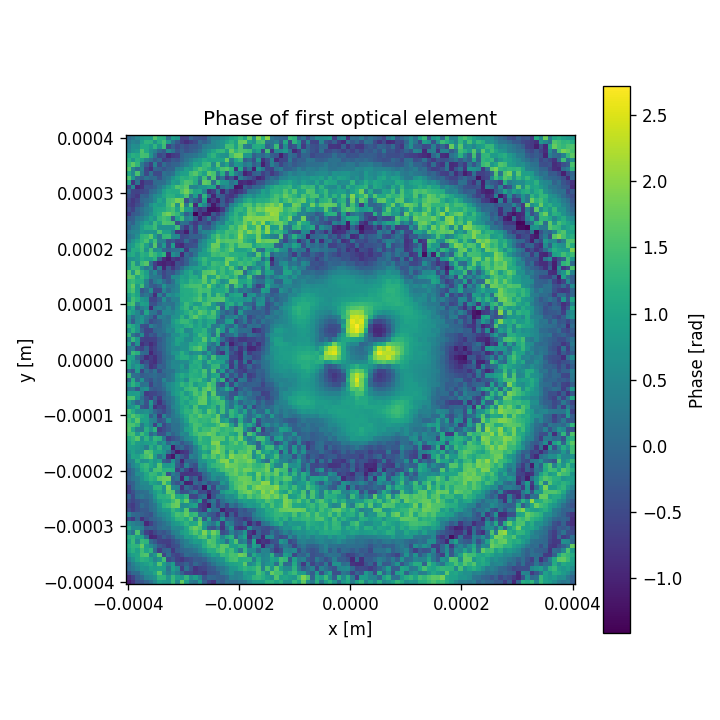

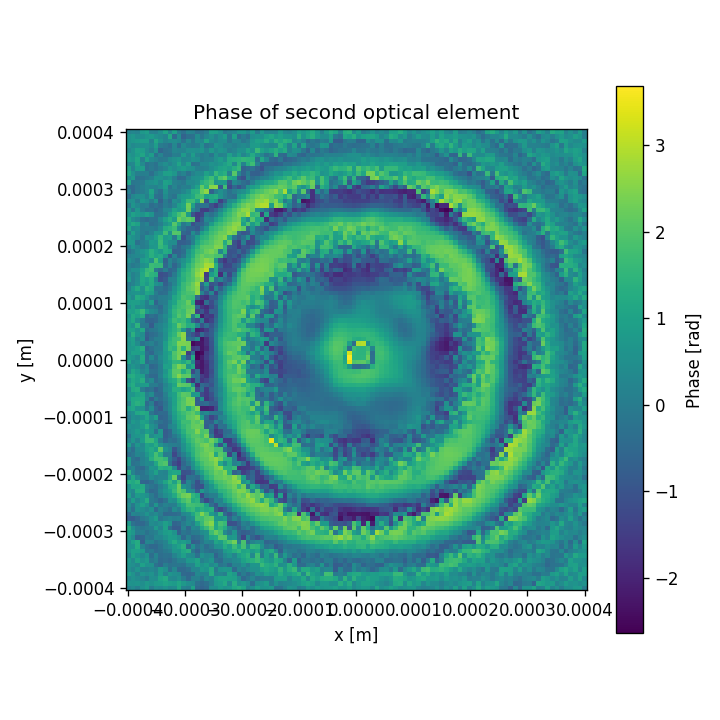

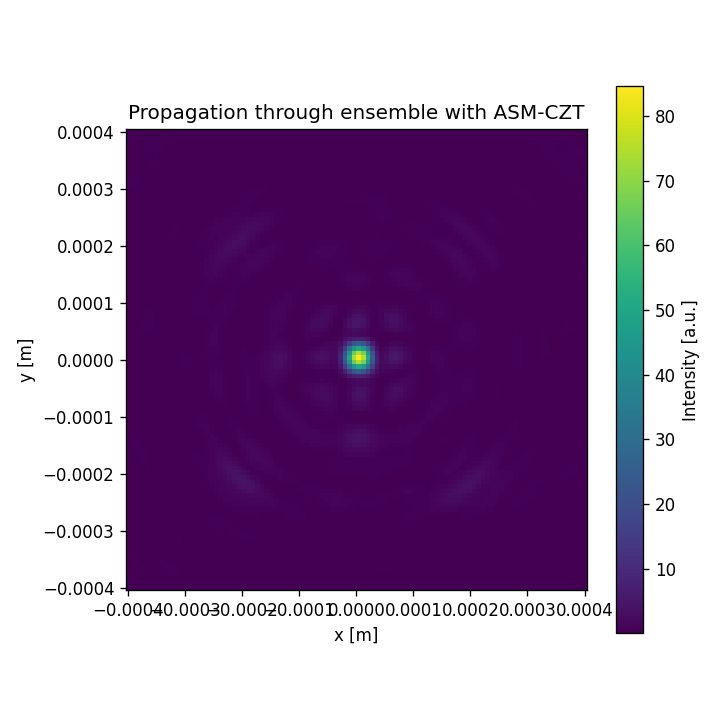

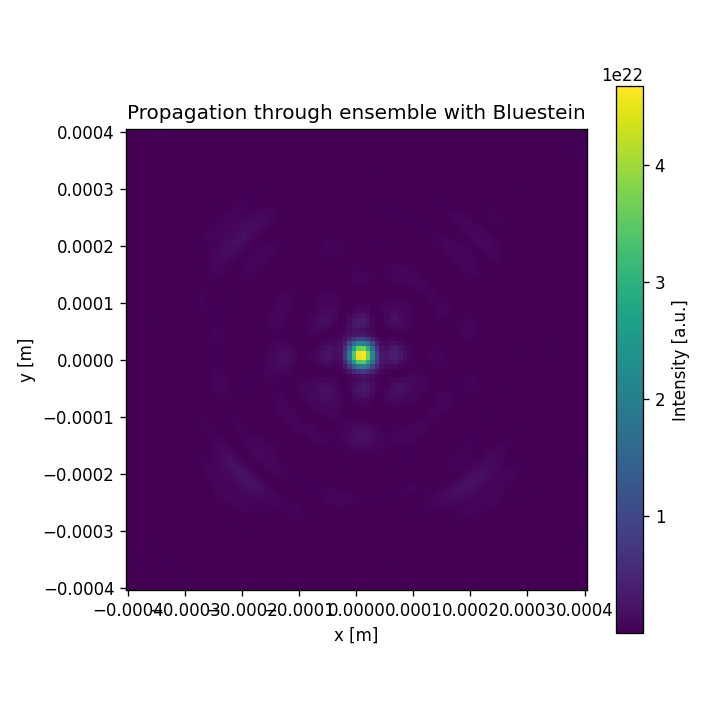

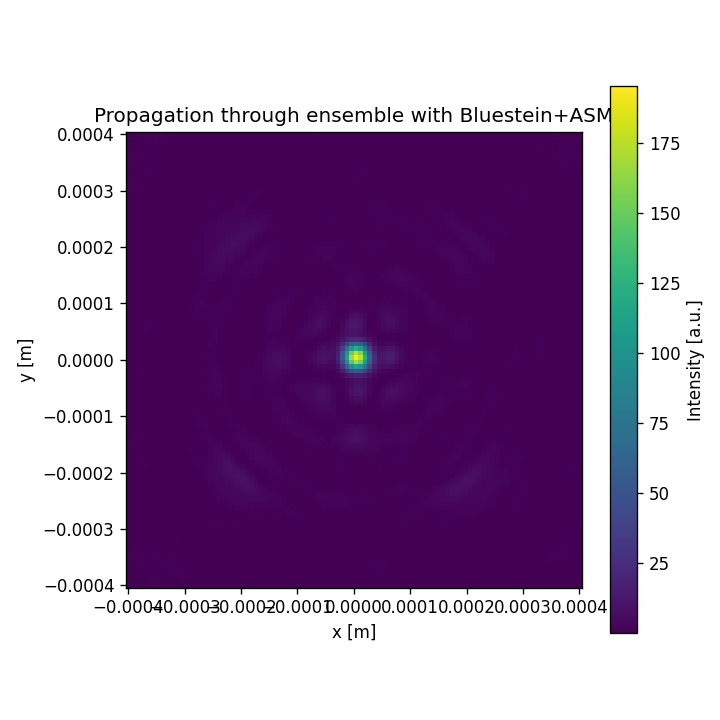

In [194]:
d1 = np.reshape(x[0:int(len(x)/2)], (len(screen_array[0].x), len(screen_array[0].y)))
d2 = np.reshape(x[int(len(x)/2):], (len(screen_array[0].x), len(screen_array[0].y)))

fig = plt.figure(figsize = (6,6)) 
xar3 = np.reshape(d1, (x_pixel, y_pixel))
plt.pcolormesh(aperture_array_phase[0].XX, aperture_array_phase[0].YY, xar3)
plt.colorbar(label = "Phase [rad]", shrink=0.8)
plt.title("Phase of first optical element")
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.gca().set_aspect('equal')
plt.tight_layout() 

fig = plt.figure(figsize = (6,6)) 
xar4 = np.reshape(d2, (x_pixel, y_pixel))
plt.pcolormesh(aperture_array_phase[1].XX, aperture_array_phase[1].YY, xar4)
plt.colorbar(label = "Phase [rad]", shrink=0.8)
plt.title("Phase of second optical element")
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.gca().set_aspect('equal')
plt.tight_layout() 

Ep = moe.optimizer.propagate(xar=[d1, d2], aperture=aperture_array_phase, screen=screen_array , wavelength=wavelength_array, \
          mask_amp = aperture_array_amp, circ_radius=None, input_field="uniform", E0=1, \
          propagation_method=["ASM","ASM"], pad_factor=2, modedef = "czt", ensemble_mode=True  )

fig = plt.figure(figsize = (6,6)) 
plt.pcolormesh(screen_array[-1].XX[:,:,-1], screen_array[-1].YY[:,:,-1], (np.abs(Ep) )**2)
plt.colorbar(label = "Intensity [a.u.]", shrink=0.8)
plt.title("Propagation through ensemble with ASM-CZT")
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.gca().set_aspect('equal')
plt.tight_layout() 

Ep = moe.optimizer.propagate(xar=[d1, d2], aperture=aperture_array_phase, screen=screen_array , wavelength=wavelength_array, \
          mask_amp = aperture_array_amp, circ_radius=None, input_field="uniform", E0=1, \
          propagation_method=["bluestein","bluestein"], pad_factor=2,  ensemble_mode=True , corr=1e10 )

fig = plt.figure(figsize = (6,6)) 
plt.pcolormesh(screen_array[-1].XX[:,:,-1], screen_array[-1].YY[:,:,-1], (np.abs(Ep) )**2)
plt.colorbar(label = "Intensity [a.u.]", shrink=0.8)
plt.title("Propagation through ensemble with Bluestein")
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.gca().set_aspect('equal')
plt.tight_layout() 

Ep = moe.optimizer.propagate(xar=[d1, d2], aperture=aperture_array_phase, screen=screen_array , wavelength=wavelength_array, \
          mask_amp = aperture_array_amp, circ_radius=None, input_field="uniform", E0=1, \
          propagation_method=["bluestein","ASM"], pad_factor=2,  ensemble_mode=True , corr=1e10 )

fig = plt.figure(figsize = (6,6)) 
plt.pcolormesh(screen_array[-1].XX[:,:,-1], screen_array[-1].YY[:,:,-1], (np.abs(Ep) )**2)
plt.colorbar(label = "Intensity [a.u.]", shrink=0.8)
plt.title("Propagation through ensemble with Bluestein+ASM")
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.gca().set_aspect('equal')
plt.tight_layout() 

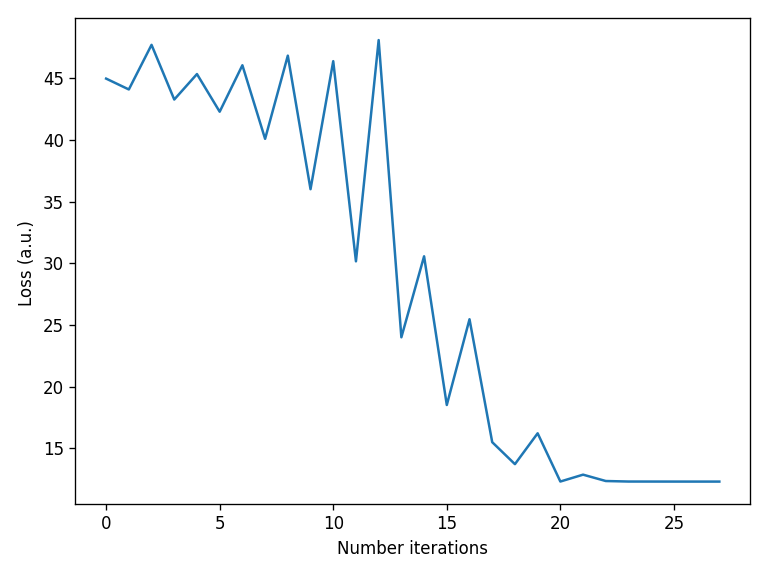

In [195]:
loss_vector = solution.loss_history 

plt.figure() 
plt.plot(loss_vector)
plt.xlabel("Number iterations")
plt.ylabel("Loss (a.u.) ")
plt.tight_layout() 